<a href="https://www.kaggle.com/code/omborse771924/retail-sales-dataset-eda?scriptVersionId=334616545" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/satyakidas07/retail-sales-dataset/retail_sales_dataset.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/satyakidas07/retail-sales-dataset/retail_sales_dataset.csv')

In [3]:
df.head()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,...,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,...,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,...,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,...,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,...,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0


In [4]:
df.tail()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
4305,ORD-00056,2020-01-21,CUST85136,Sanjay Sharma,45.0,F,West,Pune,Sports,Football,...,1871.46,0.22,6895.34,1811.03,62.59,EMI,NaN,True,Returned,9.0
4306,ORD-03458,2024-02-08,CUST09746,Karan Pillai,25.0,m,South,Chennai,Clothing,Kurta,...,3147.97,0.13,22125.94,10153.44,38.76,EMI,2.0,False,Cancelled,2.0
4307,ORD-01769,2022-02-22,CUST64190,Karan Reddy,39.0,Male,East,Guwahati,Beauty,Face Cream,...,422.45,0.02,2726.49,759.36,39.41,Credit Card,NaN,False,Delivered,5.0
4308,ORD-01738,2022-02-11,CUST50460,Amit Mehta,40.0,Female,East,Bhubaneswar,Books,Biography,...,1456.57,0.27,4835.66,2312.44,71.90,Cash on Delivery,1.0,False,Cancelled,4.0
4309,ORD-03241,2023-11-01,CUST36164,Nikhil Rao,23.0,Other,North,Delhi,Furniture,Desk,...,28349.81,0.14,211857.48,59966.21,53.88,Debit Card,2.0,False,Delivered,2.0


In [5]:
df.info

<bound method DataFrame.info of        order_id  order_date customer_id  customer_name   age  gender   region  \
0     ORD-03903  2024-08-15   CUST32603    Aarav Mehta  39.0   Other  Central   
1     ORD-02198  2022-08-16   CUST07881   Sanjay Verma  28.0    Male     West   
2     ORD-01348  2021-08-29   CUST49296   Pooja Sharma  41.0   Other     West   
3     ORD-02076  2022-07-05   CUST05587    Priya Reddy  29.0   Other     West   
4     ORD-00287  2020-05-07   CUST58035    Ritu Sharma   9.0    Male  Central   
...         ...         ...         ...            ...   ...     ...      ...   
4305  ORD-00056  2020-01-21   CUST85136  Sanjay Sharma  45.0       F     West   
4306  ORD-03458  2024-02-08   CUST09746   Karan Pillai  25.0       m    South   
4307  ORD-01769  2022-02-22   CUST64190    Karan Reddy  39.0    Male     East   
4308  ORD-01738  2022-02-11   CUST50460     Amit Mehta  40.0  Female     East   
4309  ORD-03241  2023-11-01   CUST36164     Nikhil Rao  23.0   Other    North

In [6]:
df.describe()

,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship
count,4150.000000,4170.000000,4280.000000,4143.000000,4.280000e+03,4.280000e+03,4280.000000,3932.000000,4180.000000
mean,35.335181,7.379856,10621.154428,0.202085,6.235864e+04,1.168713e+04,63.358836,3.016531,5.620335
std,35.709382,43.578352,17323.704016,0.118095,3.166998e+05,5.287522e+04,18.312281,1.413127,4.178663
min,-7.000000,-1.000000,50.260000,0.000000,3.945000e+01,1.560000e+00,-4.290000,1.000000,-1.000000
25%,26.000000,3.000000,672.222500,0.100000,2.462165e+03,7.018225e+02,50.817500,2.000000,3.000000
50%,34.000000,5.000000,2228.435000,0.210000,9.548075e+03,3.128005e+03,63.465000,3.000000,6.000000
75%,42.000000,8.000000,12717.435000,0.310000,5.006964e+04,1.040372e+04,75.650000,4.000000,8.000000
max,999.000000,999.000000,79957.920000,0.400000,1.736031e+07,2.445648e+06,133.350000,5.000000,100.000000


In [7]:
df.isnull()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4305,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4306,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4307,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4308,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

order_id                  30
order_date                30
customer_id               30
customer_name             30
age                      160
gender                    30
region                    30
city                      30
product_category          30
product_name              30
quantity                 140
unit_price                30
discount_pct             167
sales_amount              30
profit                    30
shipping_cost             30
payment_method            30
customer_satisfaction    378
return_flag               30
order_status              30
days_to_ship             130
dtype: int64

In [9]:
# ==========================
# Missing Value Treatment
# ==========================

# Numerical Columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

# Categorical Columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill Numerical Columns with Median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill Categorical Columns with Mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing Values After Treatment")
print(df.isnull().sum())

Missing Values After Treatment
order_id                 0
order_date               0
customer_id              0
customer_name            0
age                      0
gender                   0
region                   0
city                     0
product_category         0
product_name             0
quantity                 0
unit_price               0
discount_pct             0
sales_amount             0
profit                   0
shipping_cost            0
payment_method           0
customer_satisfaction    0
return_flag              0
order_status             0
days_to_ship             0
dtype: int64


In [10]:
df.duplicated().sum()

np.int64(109)

In [11]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'customer_name', 'age',
       'gender', 'region', 'city', 'product_category', 'product_name',
       'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'profit',
       'shipping_cost', 'payment_method', 'customer_satisfaction',
       'return_flag', 'order_status', 'days_to_ship'],
      dtype='object')

## EDA

DATASET SHAPE
(4310, 21)
FIRST 5 ROWS
    order_id order_date customer_id customer_name   age gender   region  \
0  ORD-03903 2024-08-15   CUST32603   Aarav Mehta  39.0  Other  Central   
1  ORD-02198 2022-08-16   CUST07881  Sanjay Verma  28.0   Male     West   
2  ORD-01348 2021-08-29   CUST49296  Pooja Sharma  41.0  Other     West   
3  ORD-02076 2022-07-05   CUST05587   Priya Reddy  29.0  Other     West   
4  ORD-00287 2020-05-07   CUST58035   Ritu Sharma   9.0   Male  Central   

        city product_category product_name  ...  unit_price  discount_pct  \
0     Raipur        Groceries        Sugar  ...      346.32          0.21   
1     Mumbai           Beauty    Sunscreen  ...      858.66          0.08   
2      Surat        Furniture         Sofa  ...    25941.32          0.14   
3  Ahmedabad        Furniture    Bed Frame  ...    22071.92          0.17   
4     Nagpur        Groceries  Cooking Oil  ...      320.06          0.31   

   sales_amount    profit  shipping_cost  paymen

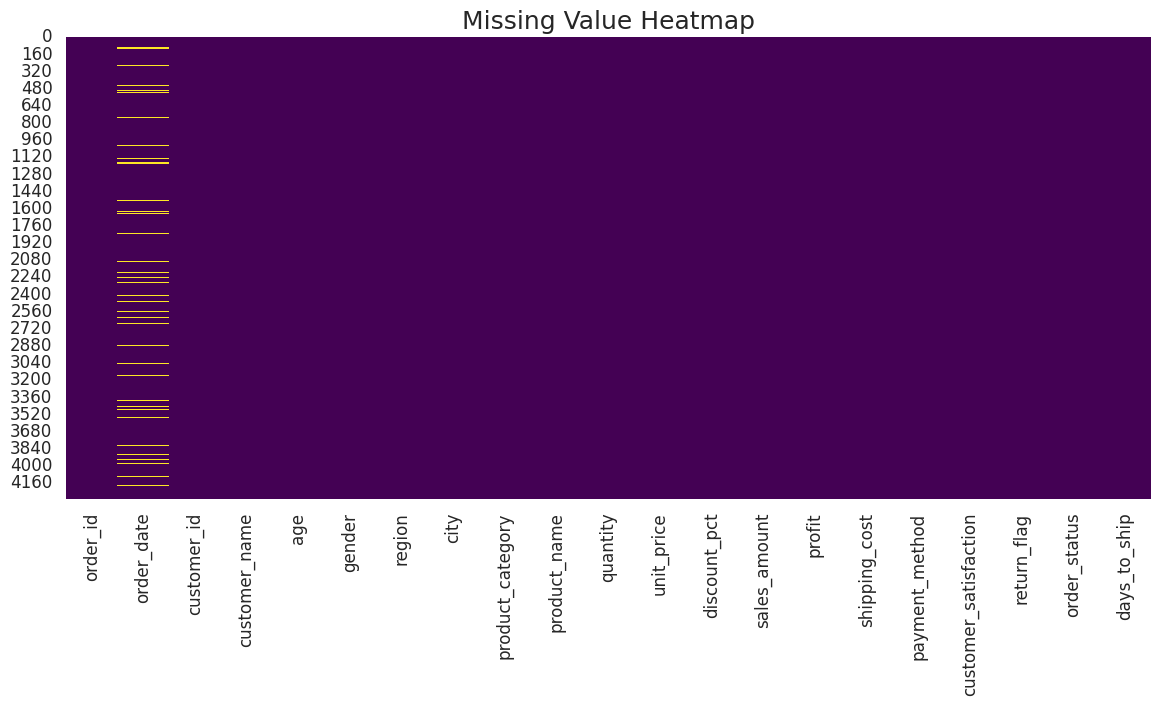


Numerical Columns
Index(['age', 'quantity', 'unit_price', 'discount_pct', 'sales_amount',
       'profit', 'shipping_cost', 'customer_satisfaction', 'days_to_ship'],
      dtype='object')

Categorical Columns
Index(['order_id', 'customer_id', 'customer_name', 'gender', 'region', 'city',
       'product_category', 'product_name', 'payment_method', 'order_status'],
      dtype='object')


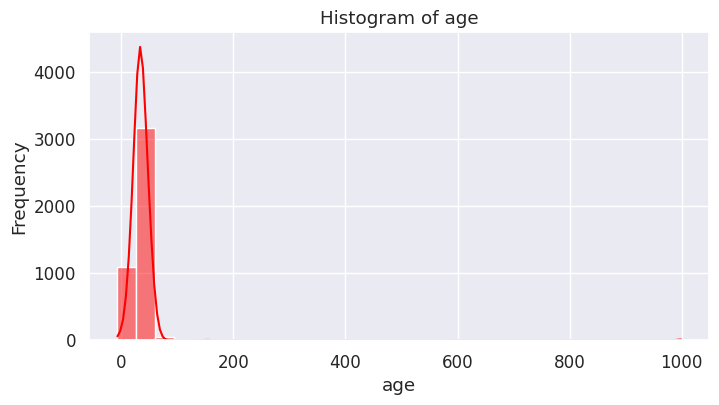

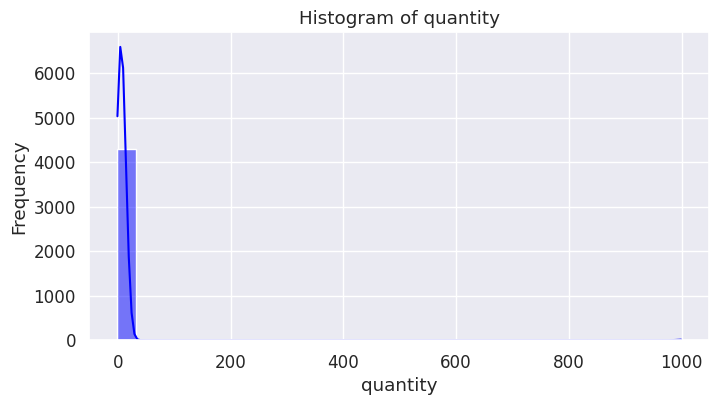

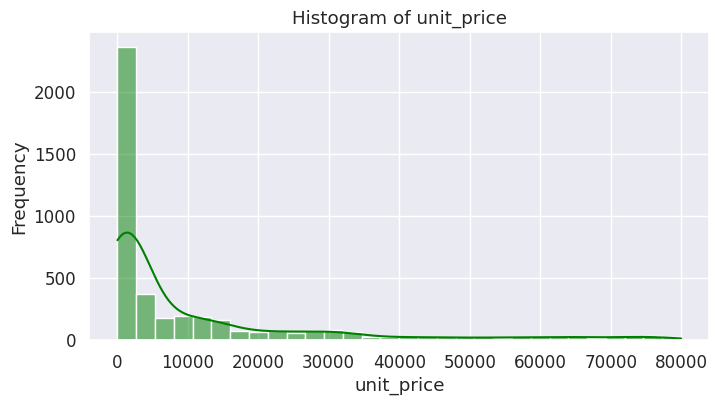

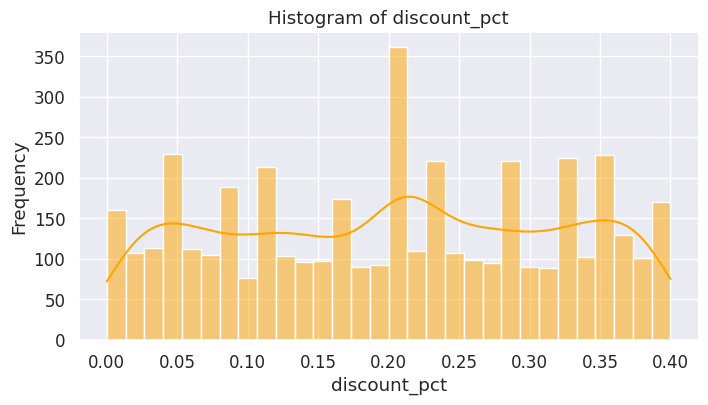

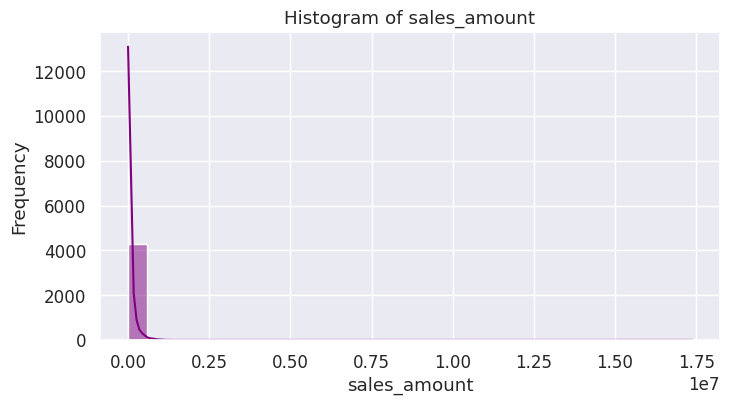

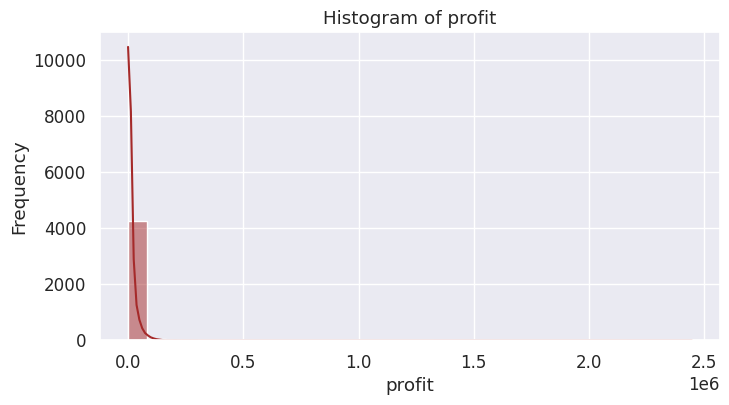

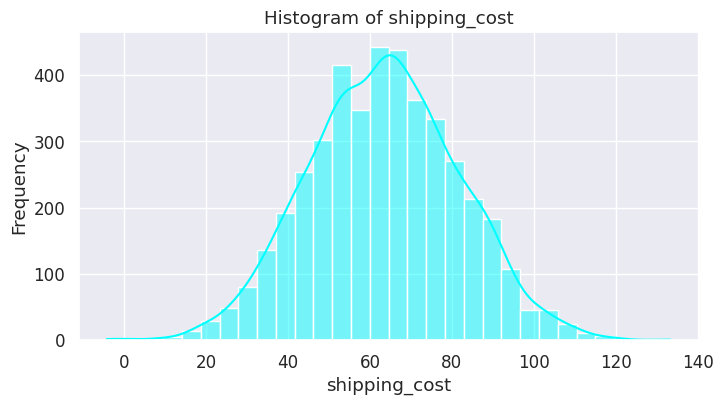

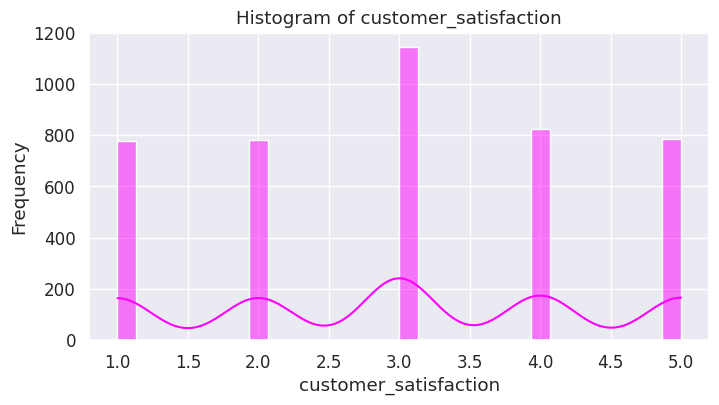

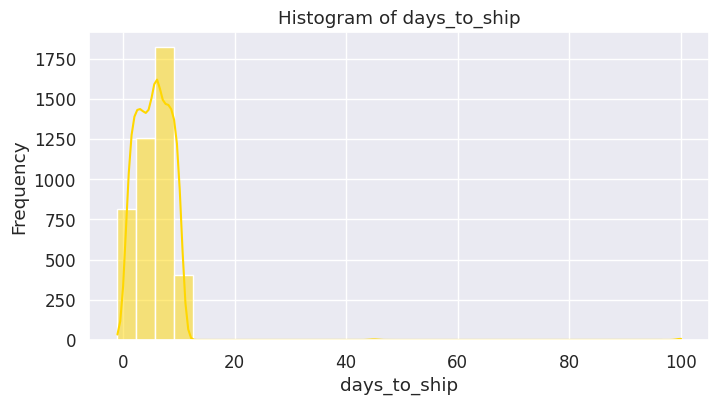

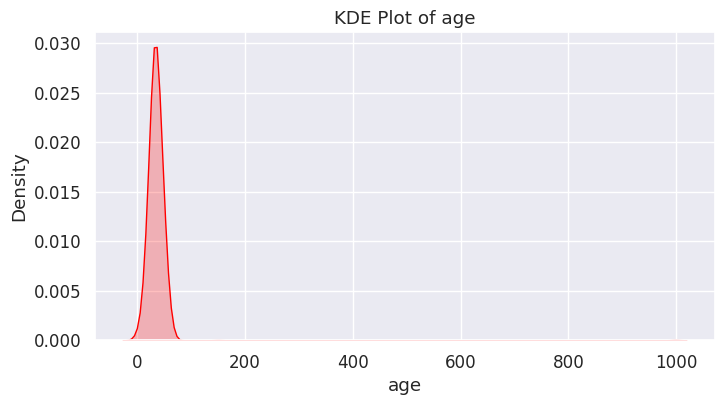

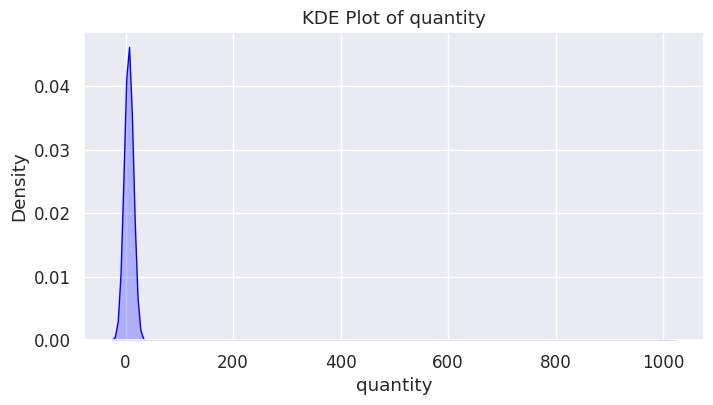

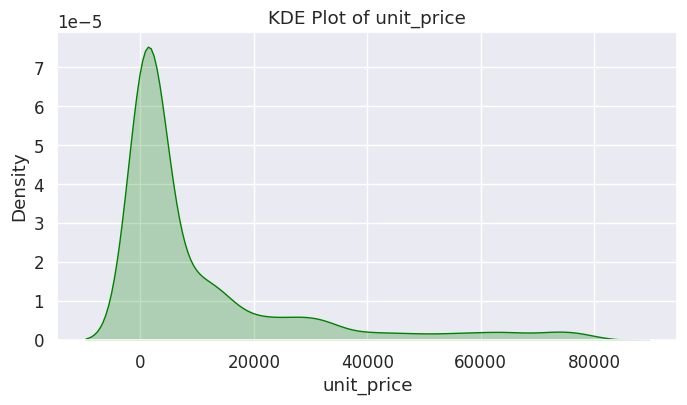

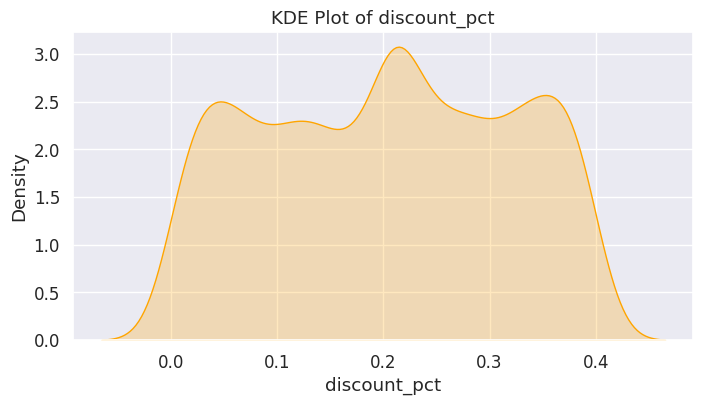

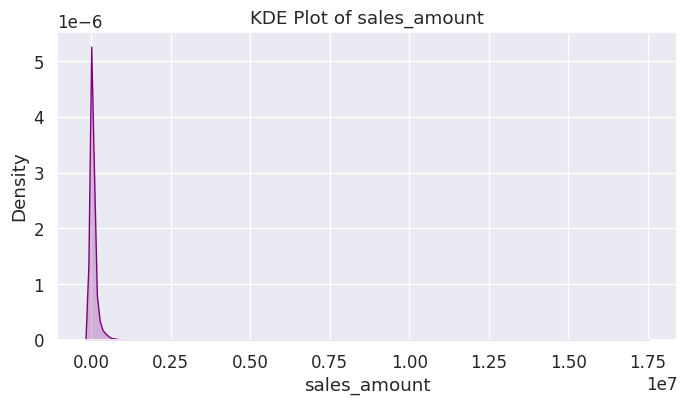

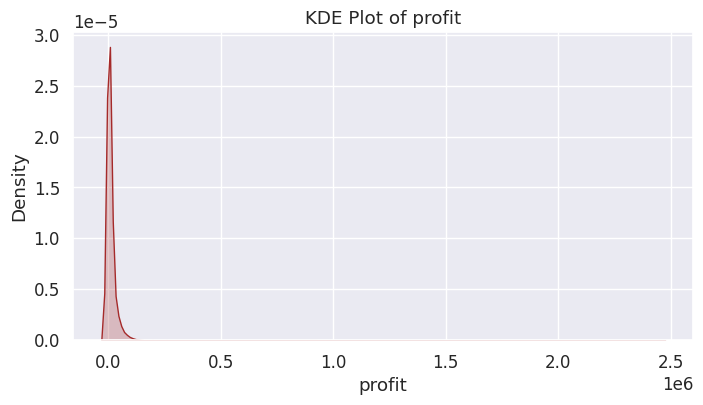

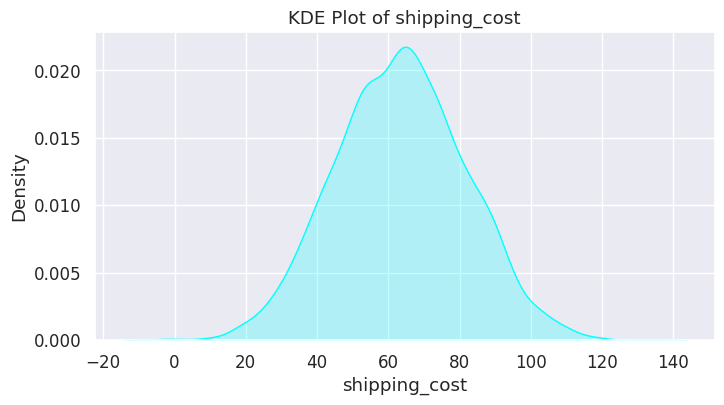

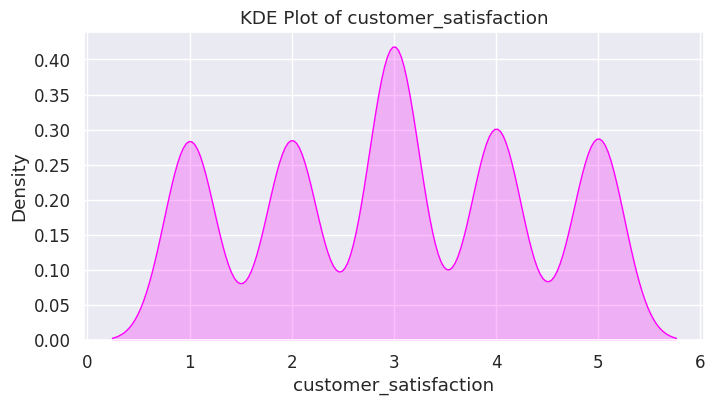

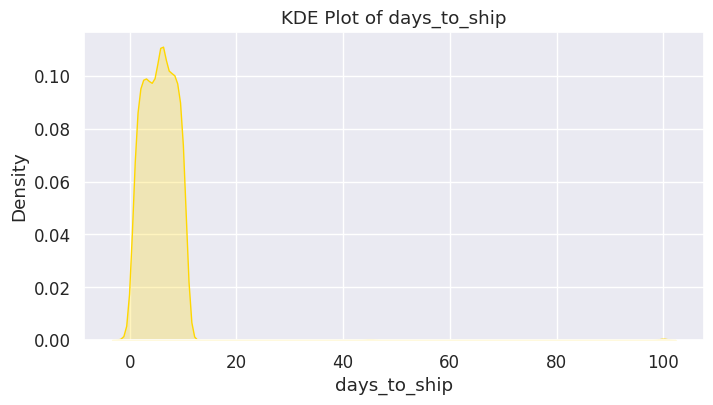

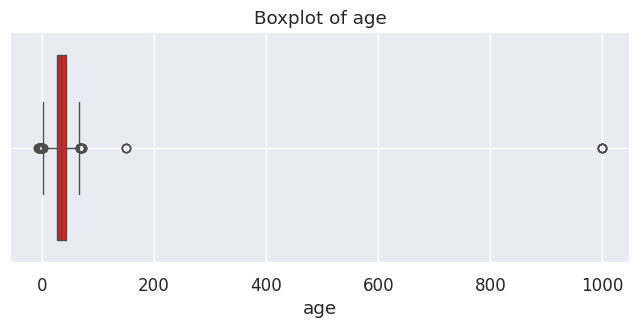

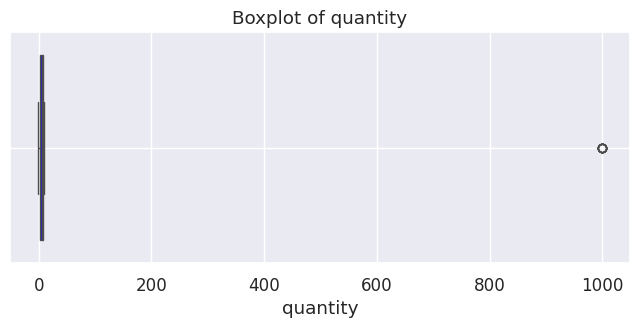

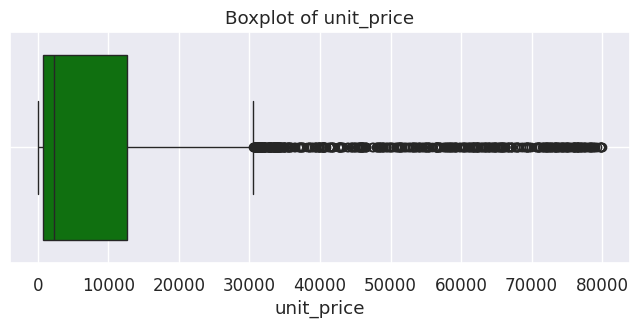

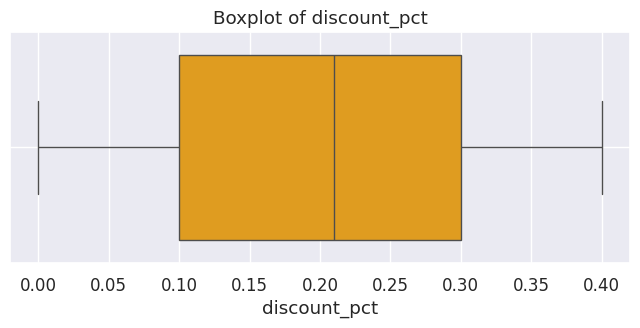

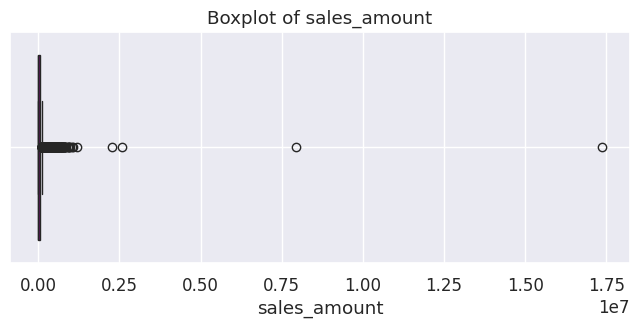

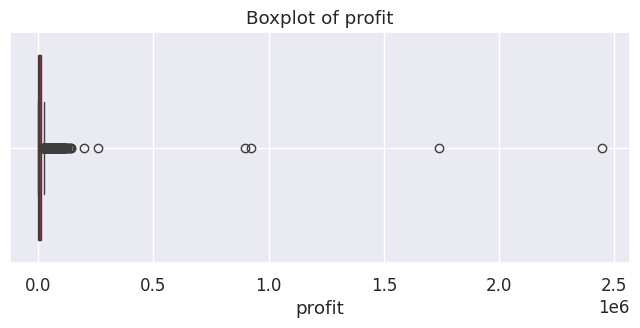

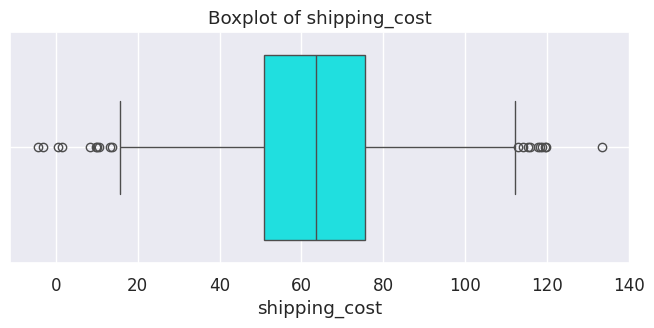

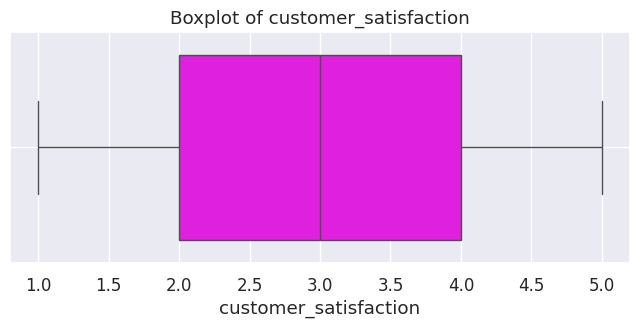

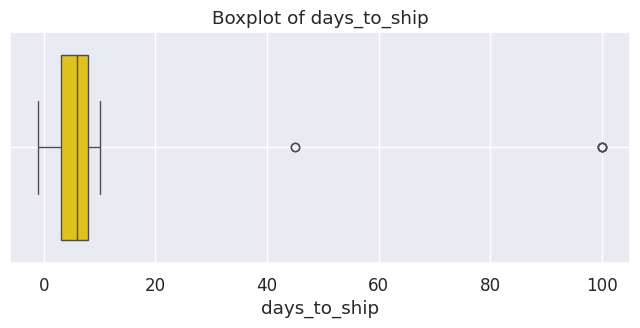

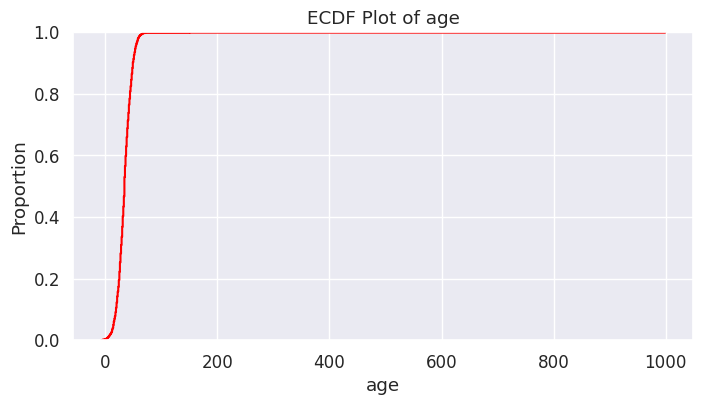

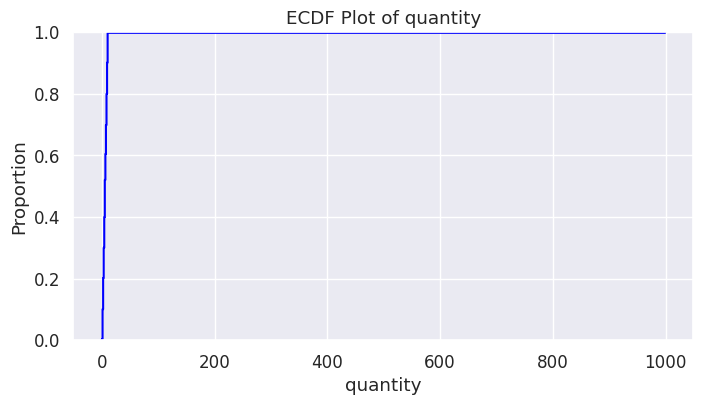

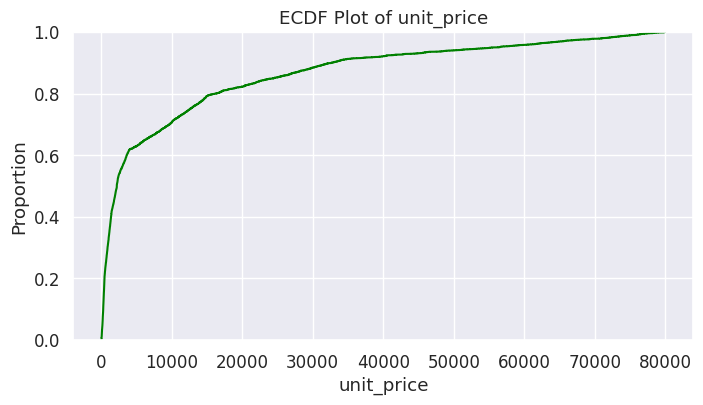

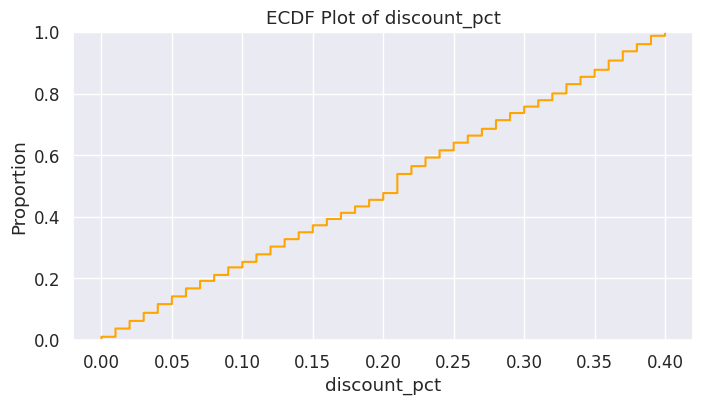

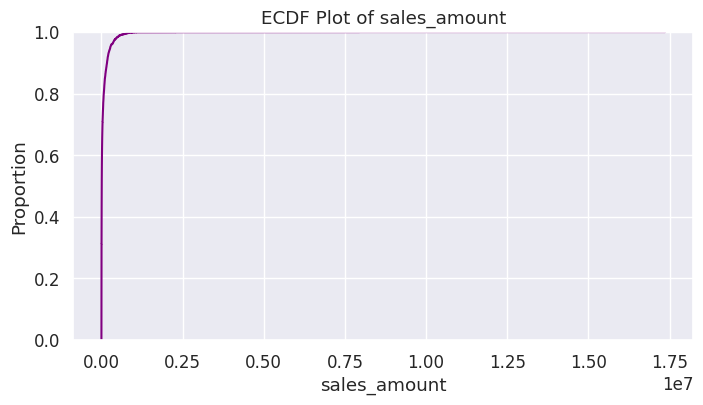

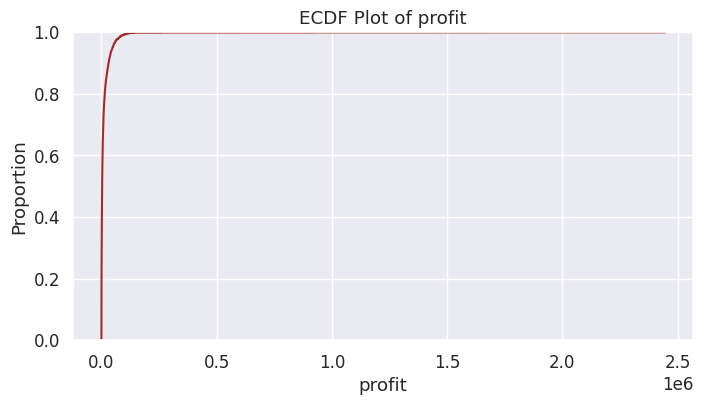

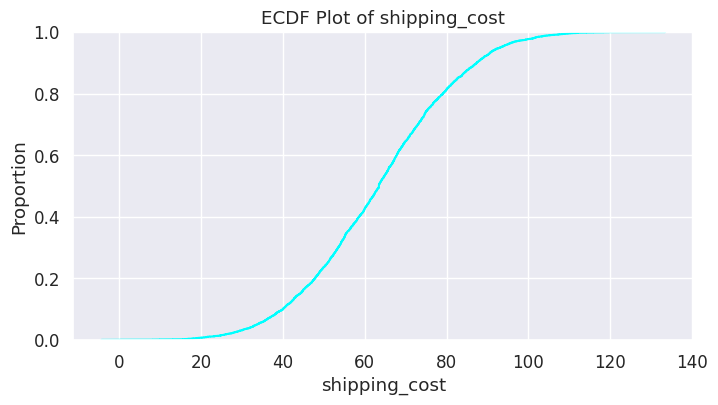

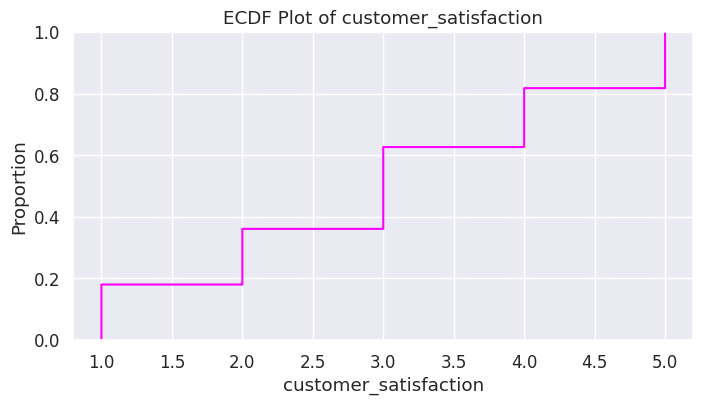

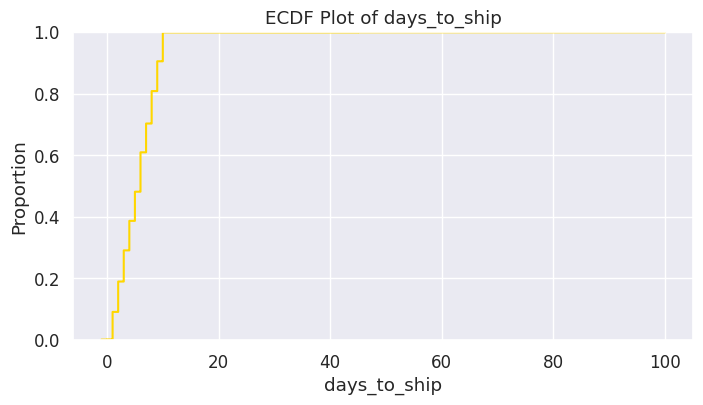

PART 1 COMPLETED SUCCESSFULLY


In [12]:
# ==========================================================
# SALES DATASET EDA - PART 1
# Dataset Overview + Missing Values + Histograms + KDE + Boxplots
# ==========================================================

# ==========================
# IMPORT LIBRARIES
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.1)

data = df.copy()

# ==========================
# CONVERT DATE COLUMN
# ==========================

data["order_date"] = pd.to_datetime(
    data["order_date"],
    errors="coerce"
)

# ==========================
# DATASET OVERVIEW
# ==========================

print("="*80)
print("DATASET SHAPE")
print(data.shape)

print("="*80)
print("FIRST 5 ROWS")
print(data.head())

print("="*80)
print("DATA INFORMATION")
print(data.info())

print("="*80)
print("MISSING VALUES")
print(data.isnull().sum())

print("="*80)
print("STATISTICAL SUMMARY")
print(data.describe(include="all"))

# ==========================
# MISSING VALUE HEATMAP
# ==========================

plt.figure(figsize=(14,6))

sns.heatmap(
    data.isnull(),
    cmap="viridis",
    cbar=False
)

plt.title("Missing Value Heatmap", fontsize=18)

plt.show()

# ==========================
# NUMERICAL & CATEGORICAL COLUMNS
# ==========================

num_cols = data.select_dtypes(include=np.number).columns
cat_cols = data.select_dtypes(include="object").columns

print("\nNumerical Columns")
print(num_cols)

print("\nCategorical Columns")
print(cat_cols)

# ==========================
# HISTOGRAMS
# ==========================

colors = [
    "red","blue","green","orange",
    "purple","brown","cyan","magenta",
    "gold","pink","olive","teal"
]

for i, col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.histplot(
        data=data,
        x=col,
        bins=30,
        kde=True,
        color=colors[i % len(colors)]
    )

    plt.title(f"Histogram of {col}")

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.grid(True)

    plt.show()

# ==========================
# KDE PLOTS
# ==========================

for i, col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        data=data[col],
        fill=True,
        color=colors[i % len(colors)]
    )

    plt.title(f"KDE Plot of {col}")

    plt.grid(True)

    plt.show()

# ==========================
# BOXPLOTS
# ==========================

for i, col in enumerate(num_cols):

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=data[col],
        color=colors[i % len(colors)]
    )

    plt.title(f"Boxplot of {col}")

    plt.grid(True)

    plt.show()

# ==========================
# ECDF PLOTS
# ==========================

for i, col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.ecdfplot(
        data=data,
        x=col,
        color=colors[i % len(colors)]
    )

    plt.title(f"ECDF Plot of {col}")

    plt.grid(True)

    plt.show()

print("="*80)
print("PART 1 COMPLETED SUCCESSFULLY")
print("="*80)

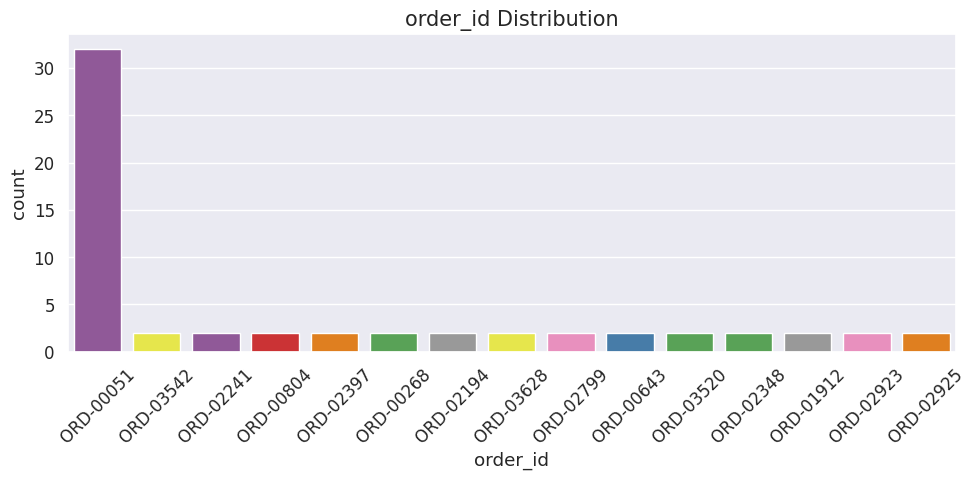

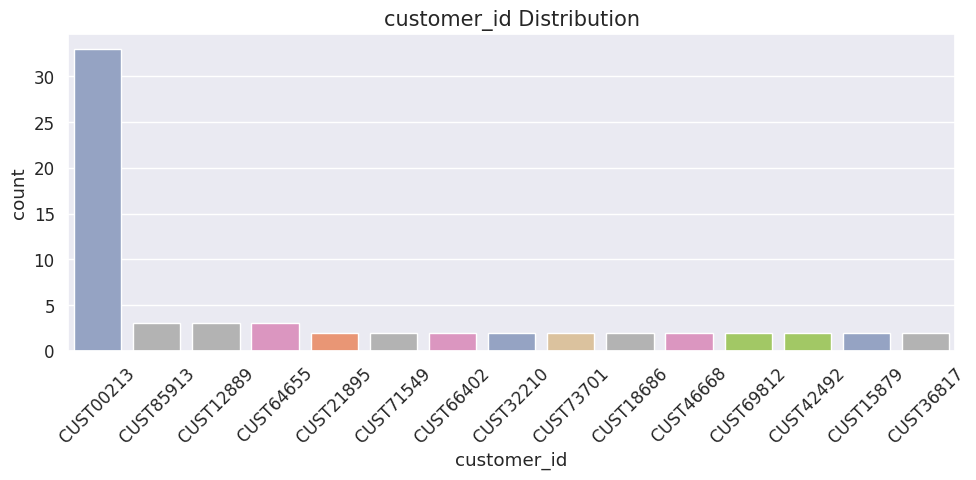

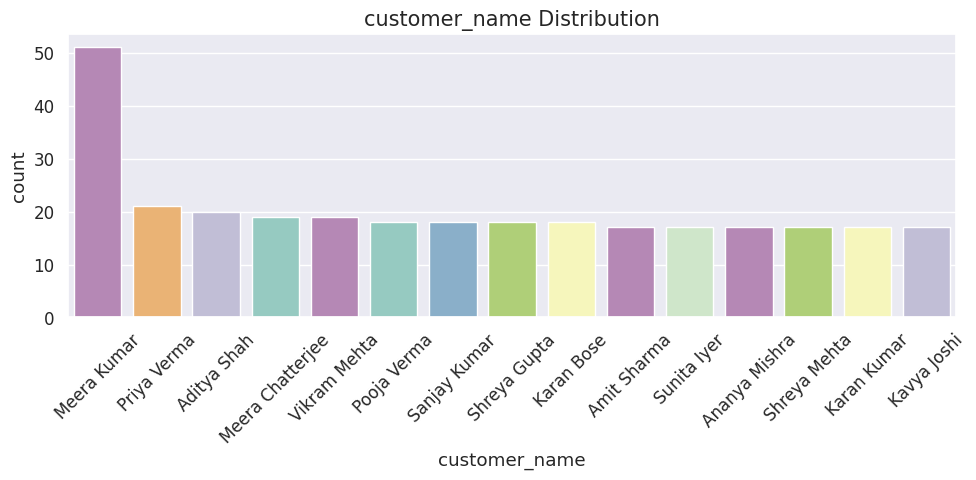

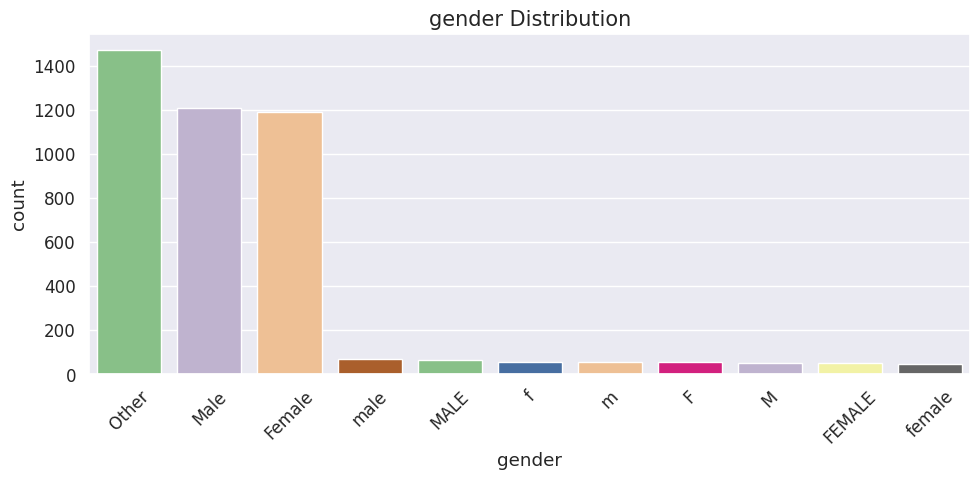

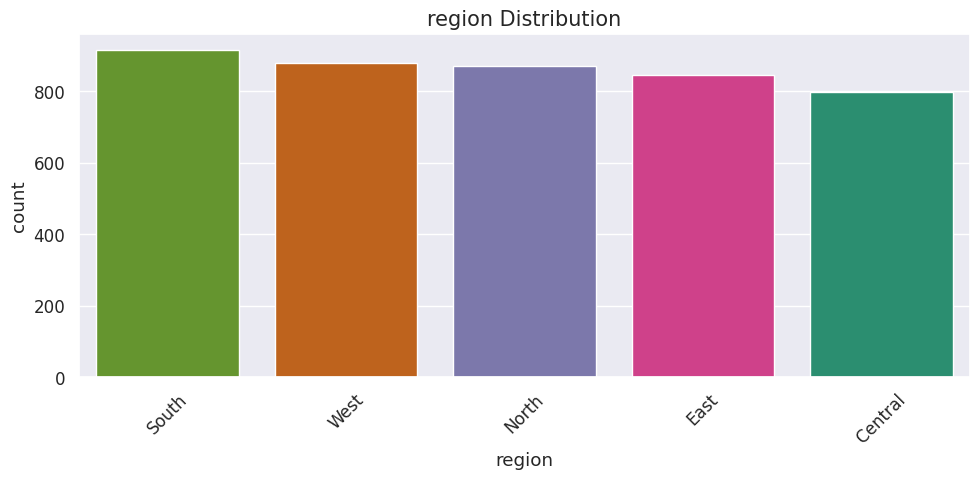

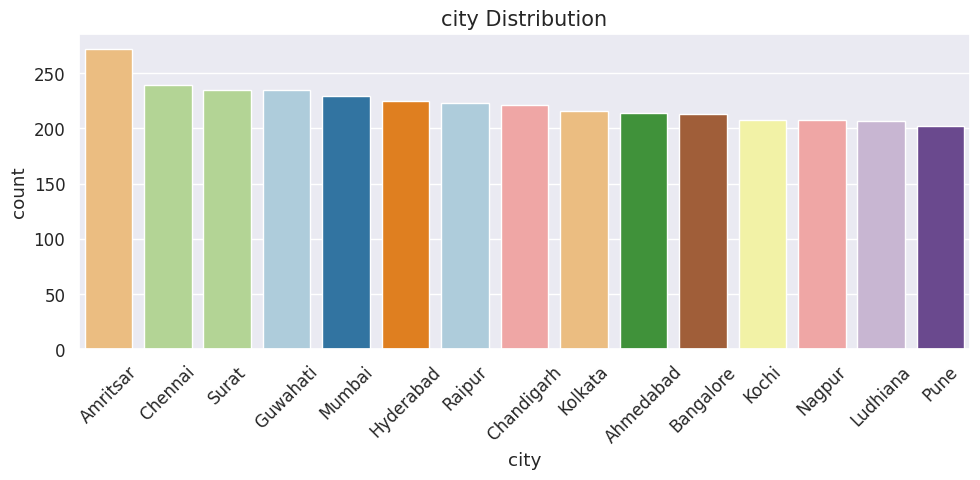

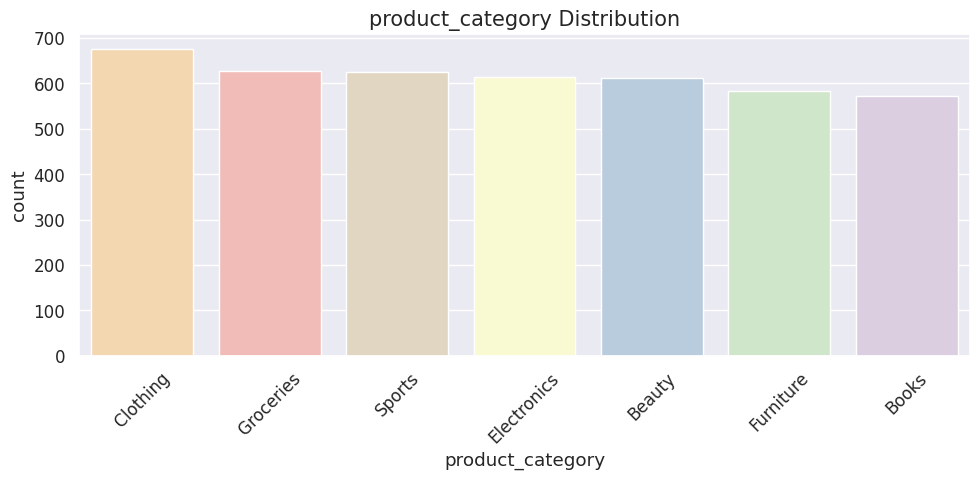

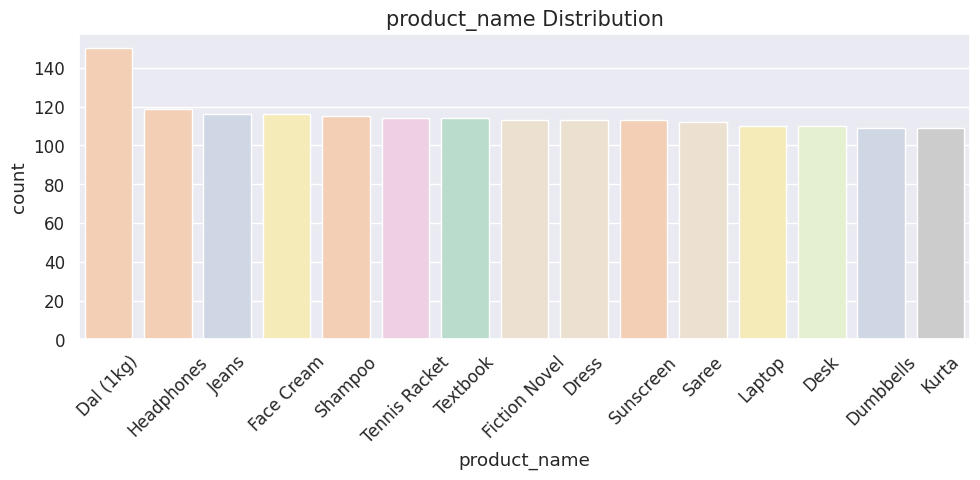

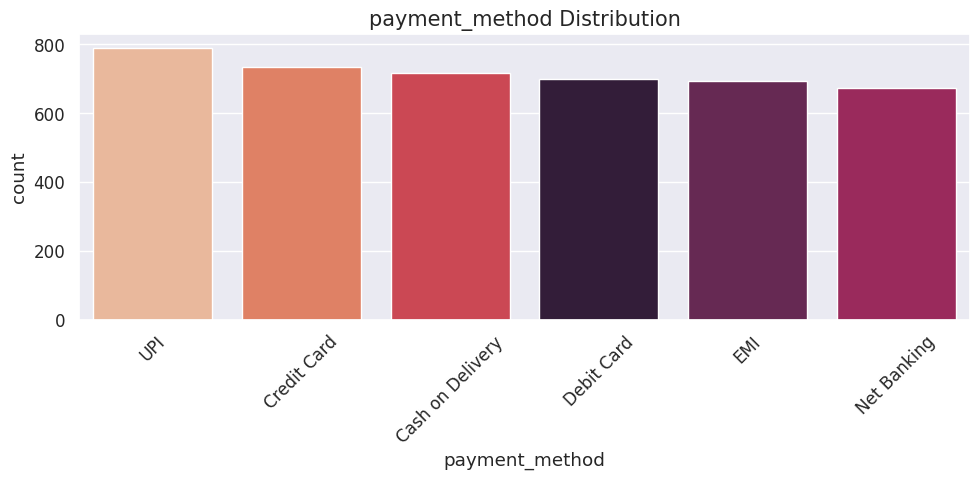

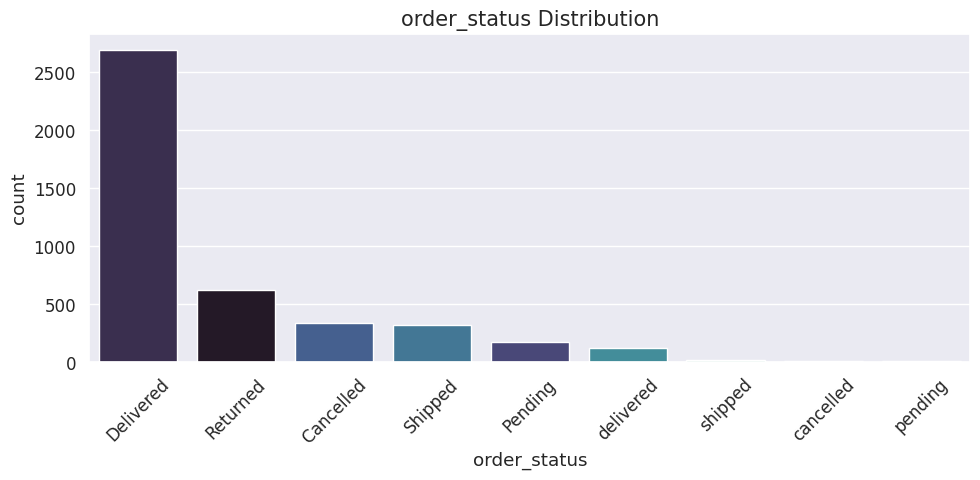

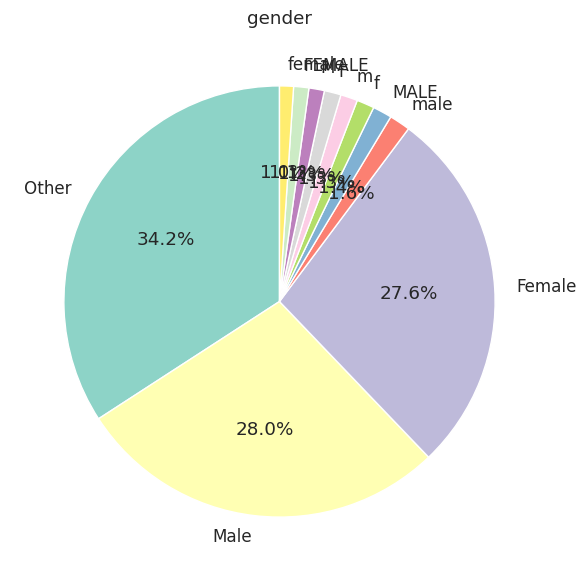

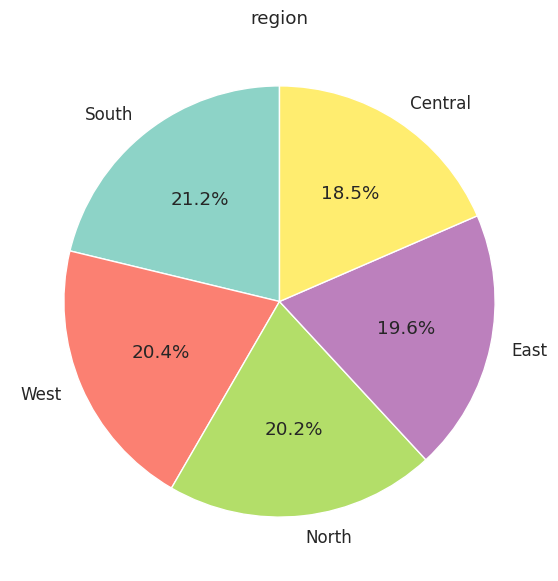

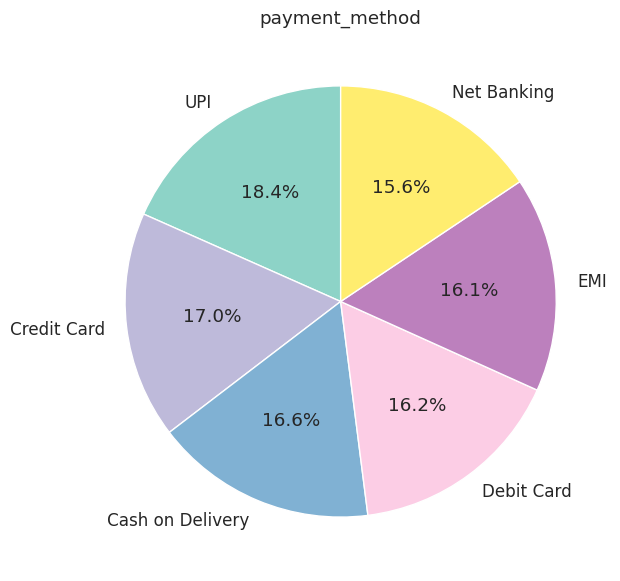

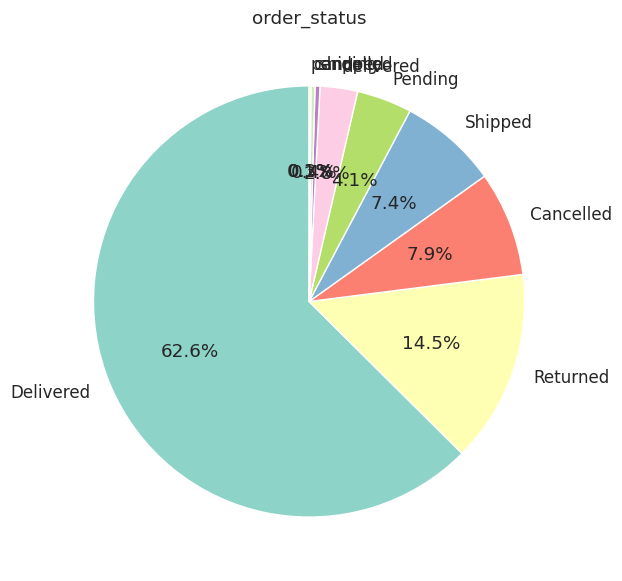

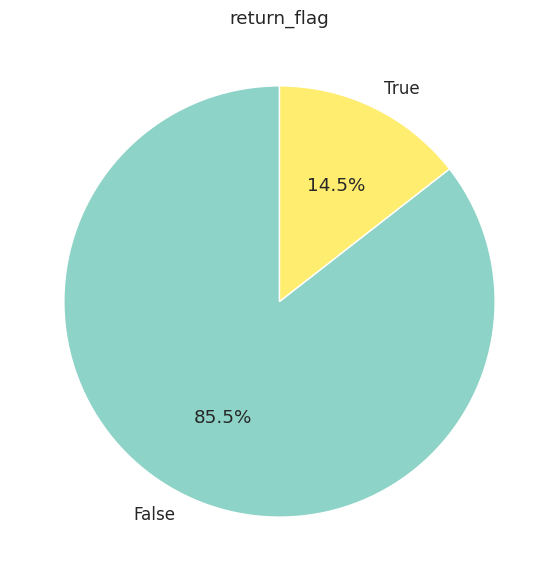

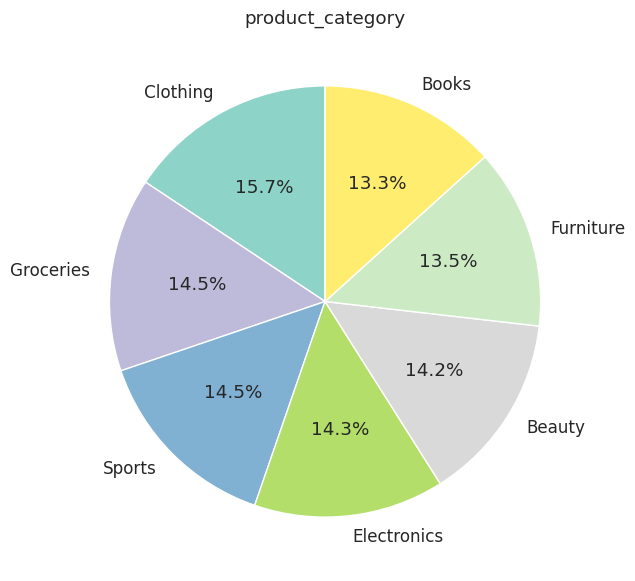

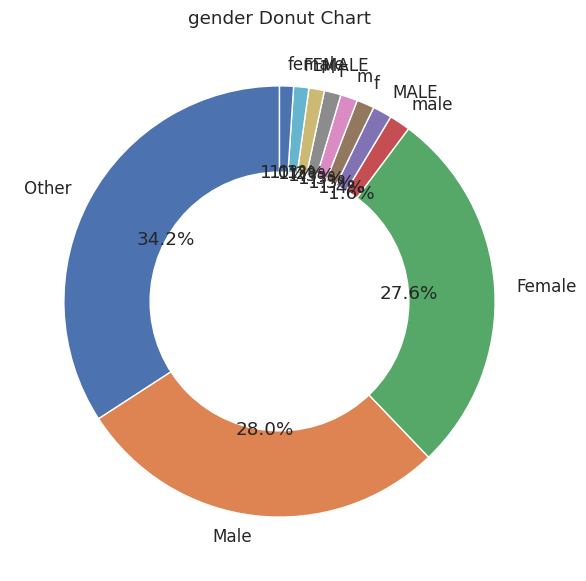

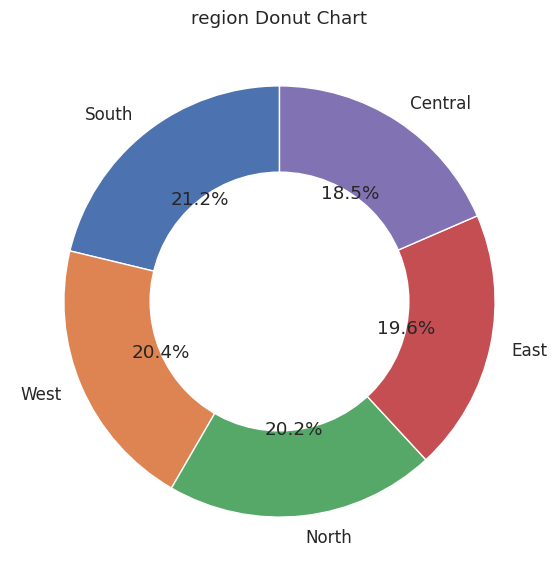

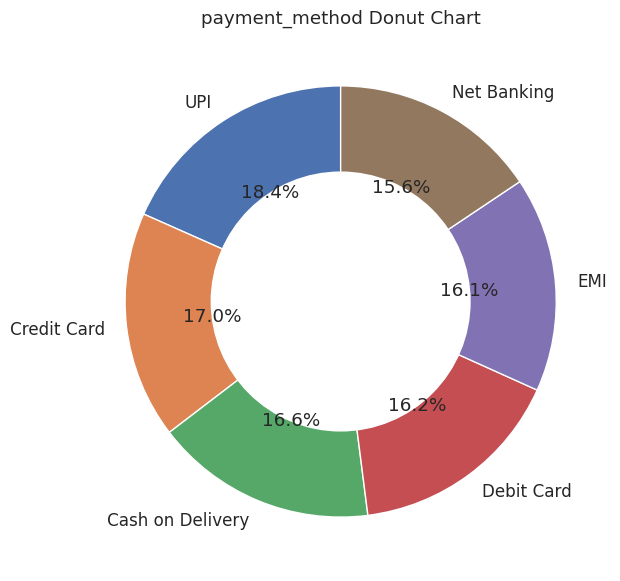

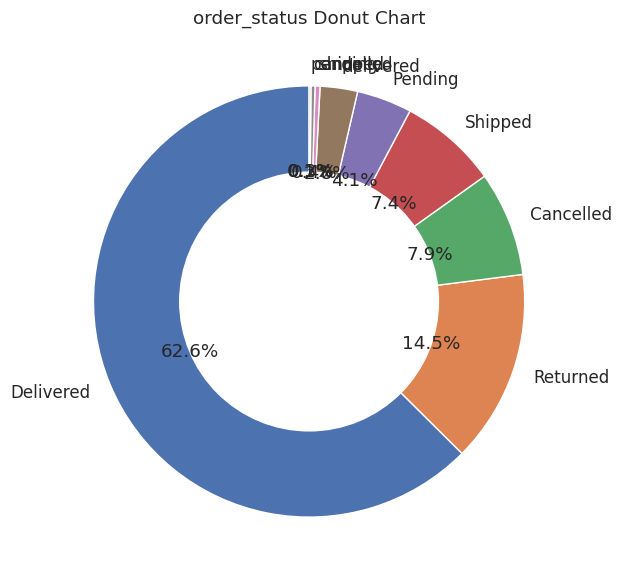

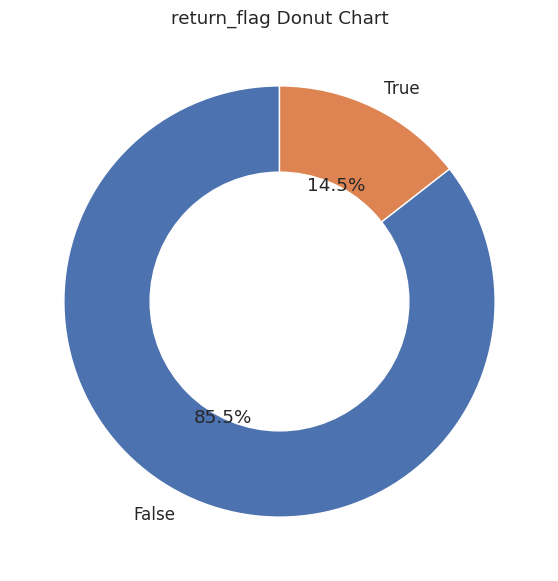

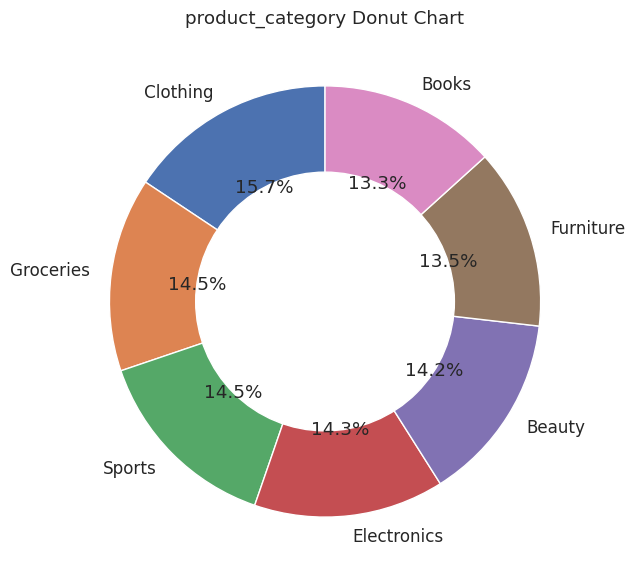

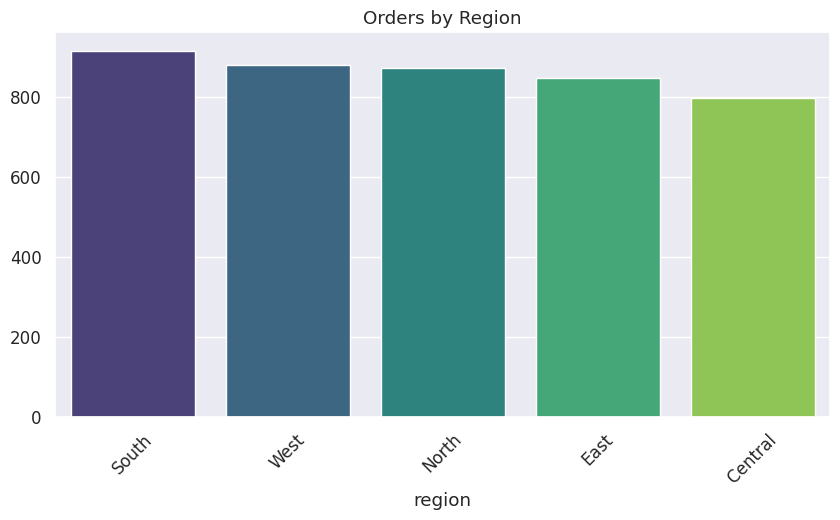

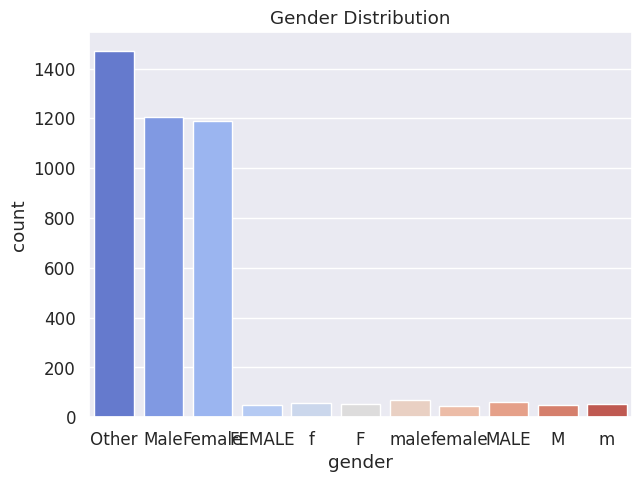

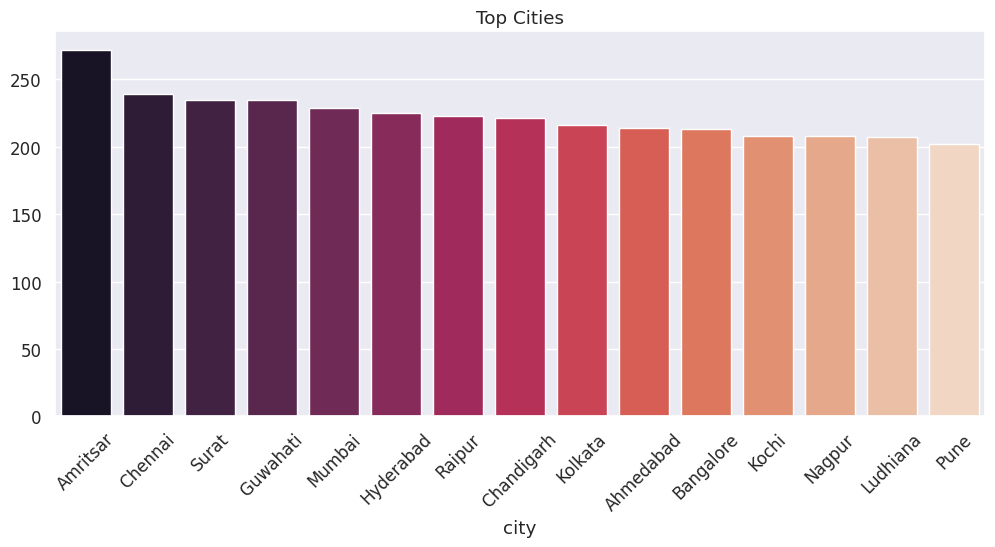

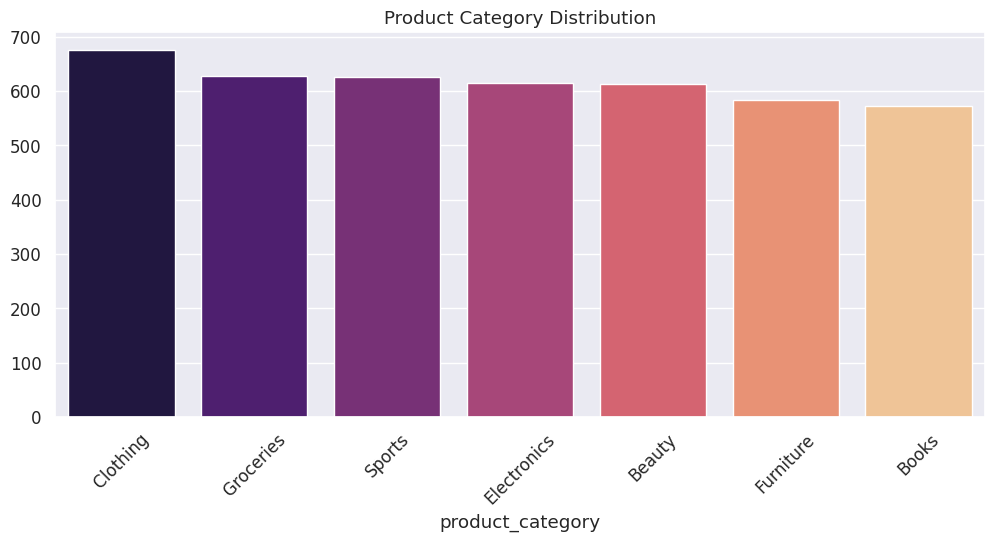

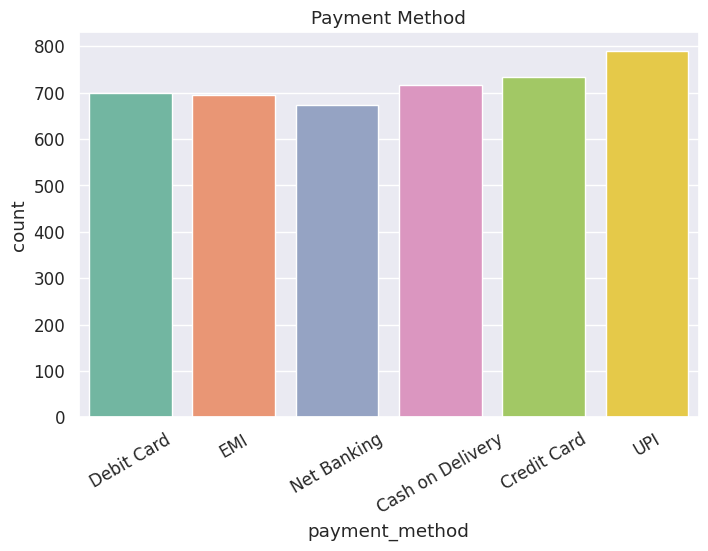

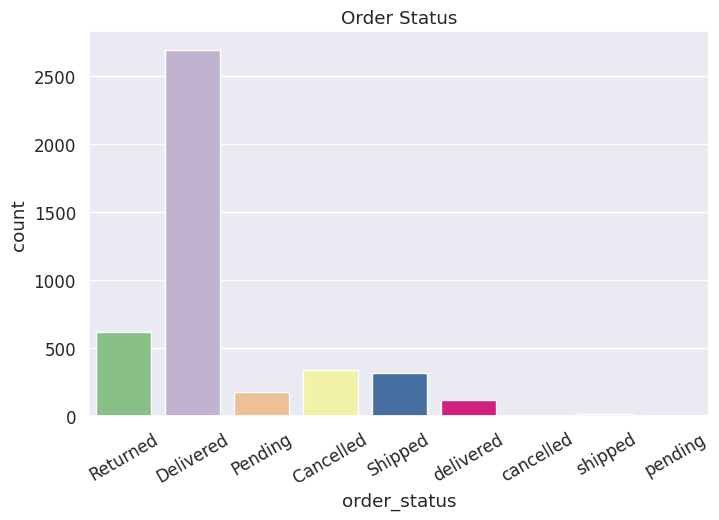

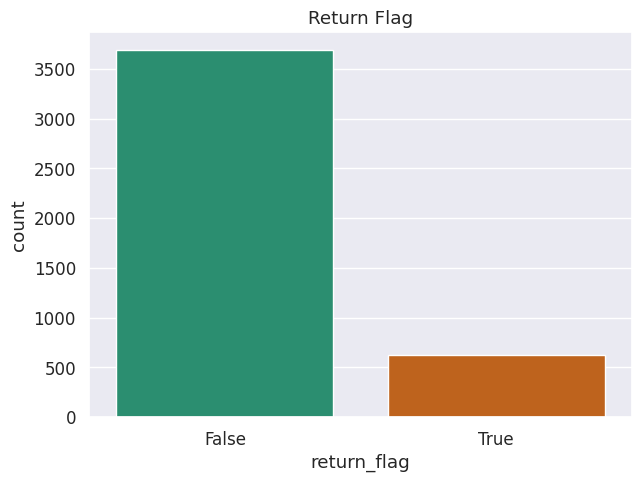

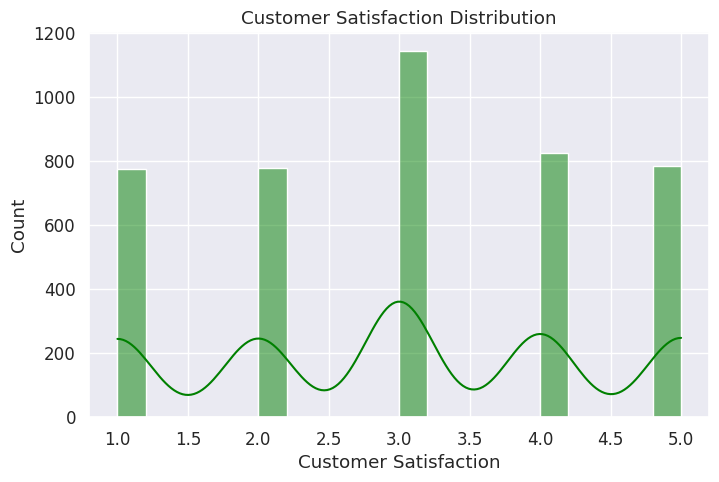

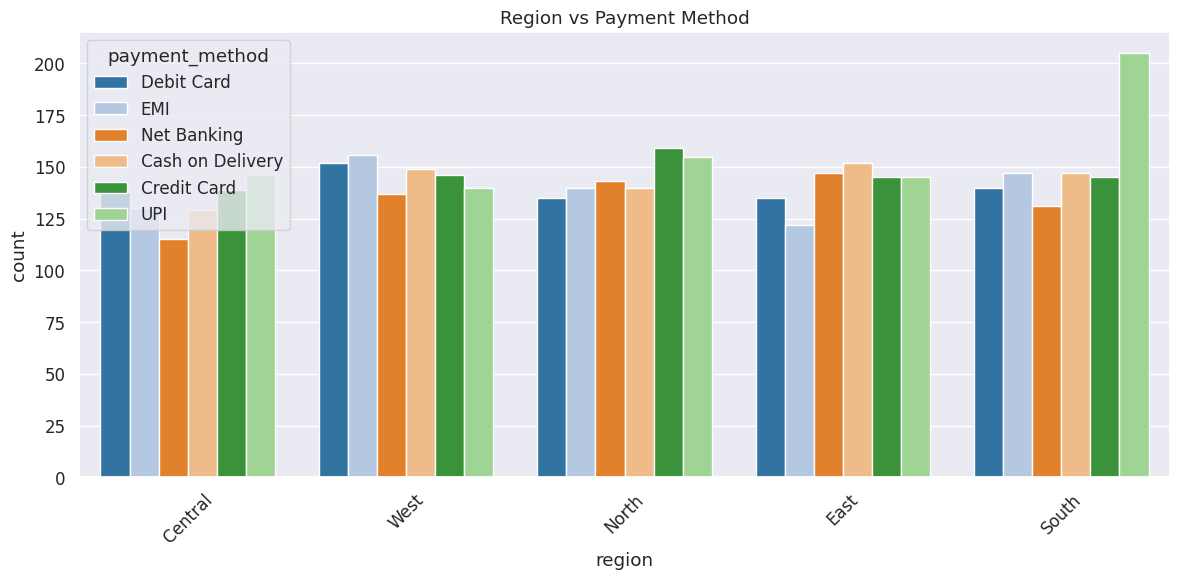

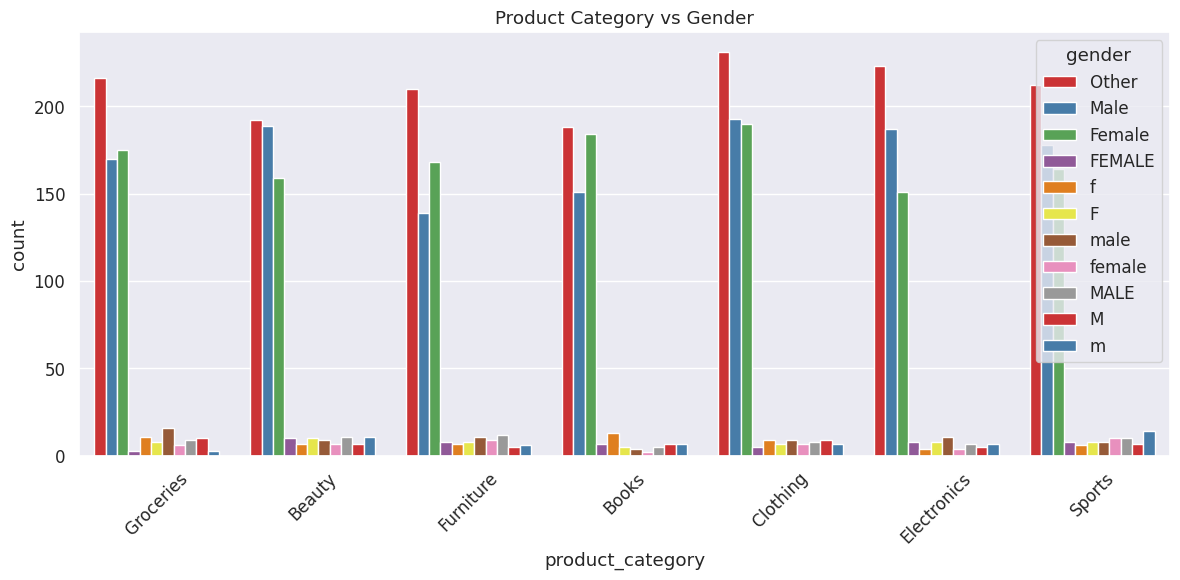

PART 2 COMPLETED SUCCESSFULLY


In [13]:
# ==========================================================
# SALES DATASET EDA - PART 2
# Categorical Visualizations
# ==========================================================

palettes = [
    "Set1","Set2","Set3","Accent","Dark2",
    "Paired","Pastel1","Pastel2",
    "rocket","mako","crest",
    "flare","viridis","Spectral","coolwarm"
]

# ==========================================================
# COUNTPLOTS FOR ALL CATEGORICAL COLUMNS
# ==========================================================

for i, col in enumerate(cat_cols):

    plt.figure(figsize=(10,5))

    order = data[col].value_counts().head(15).index

    sns.countplot(
        data=data,
        x=col,
        order=order,
        hue=col,
        palette=palettes[i % len(palettes)],
        legend=False
    )

    plt.title(f"{col} Distribution", fontsize=15)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

# ==========================================================
# PIE CHARTS
# ==========================================================

pie_columns = [
    "gender",
    "region",
    "payment_method",
    "order_status",
    "return_flag",
    "product_category"
]

for col in pie_columns:

    if col in data.columns:

        plt.figure(figsize=(7,7))

        data[col].value_counts().plot(
            kind="pie",
            autopct="%1.1f%%",
            startangle=90,
            cmap="Set3"
        )

        plt.title(col)

        plt.ylabel("")

        plt.show()

# ==========================================================
# DONUT CHARTS
# ==========================================================

for col in pie_columns:

    if col in data.columns:

        counts = data[col].value_counts()

        fig, ax = plt.subplots(figsize=(7,7))

        ax.pie(
            counts,
            labels=counts.index,
            autopct="%1.1f%%",
            startangle=90
        )

        centre = plt.Circle((0,0),0.60,fc="white")

        fig.gca().add_artist(centre)

        plt.title(col + " Donut Chart")

        plt.show()

# ==========================================================
# REGION ANALYSIS
# ==========================================================

plt.figure(figsize=(10,5))

region = data["region"].value_counts()

sns.barplot(
    x=region.index,
    y=region.values,
    hue=region.index,
    palette="viridis",
    legend=False
)

plt.title("Orders by Region")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# GENDER ANALYSIS
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(
    data=data,
    x="gender",
    hue="gender",
    palette="coolwarm",
    legend=False
)

plt.title("Gender Distribution")

plt.show()

# ==========================================================
# CITY ANALYSIS
# ==========================================================

plt.figure(figsize=(12,5))

city = data["city"].value_counts().head(15)

sns.barplot(
    x=city.index,
    y=city.values,
    hue=city.index,
    palette="rocket",
    legend=False
)

plt.title("Top Cities")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# PRODUCT CATEGORY
# ==========================================================

plt.figure(figsize=(12,5))

category = data["product_category"].value_counts()

sns.barplot(
    x=category.index,
    y=category.values,
    hue=category.index,
    palette="magma",
    legend=False
)

plt.title("Product Category Distribution")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# PAYMENT METHOD
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="payment_method",
    hue="payment_method",
    palette="Set2",
    legend=False
)

plt.title("Payment Method")

plt.xticks(rotation=30)

plt.show()

# ==========================================================
# ORDER STATUS
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="order_status",
    hue="order_status",
    palette="Accent",
    legend=False
)

plt.title("Order Status")

plt.xticks(rotation=30)

plt.show()

# ==========================================================
# RETURN FLAG
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(
    data=data,
    x="return_flag",
    hue="return_flag",
    palette="Dark2",
    legend=False
)

plt.title("Return Flag")

plt.show()

# ==========================================================
# CUSTOMER SATISFACTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["customer_satisfaction"],
    bins=20,
    kde=True,
    color="green"
)

plt.title("Customer Satisfaction Distribution")

plt.xlabel("Customer Satisfaction")

plt.show()

# ==========================================================
# REGION VS PAYMENT METHOD
# ==========================================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=data,
    x="region",
    hue="payment_method",
    palette="tab20"
)

plt.title("Region vs Payment Method")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ==========================================================
# PRODUCT CATEGORY VS GENDER
# ==========================================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=data,
    x="product_category",
    hue="gender",
    palette="Set1"
)

plt.title("Product Category vs Gender")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

print("="*80)
print("PART 2 COMPLETED SUCCESSFULLY")
print("="*80)

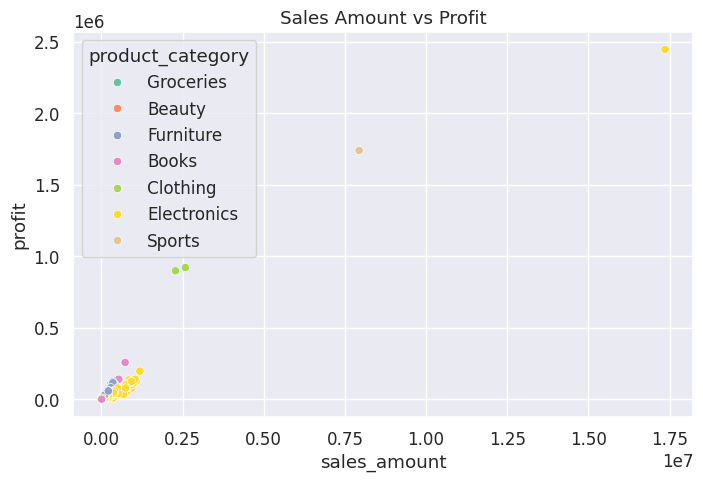

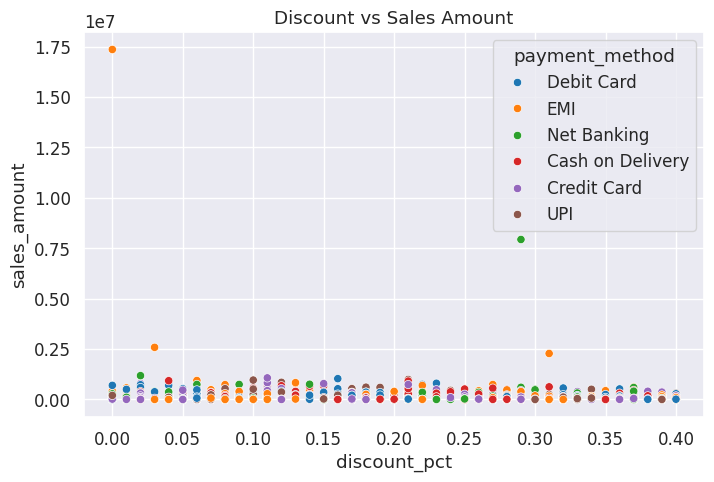

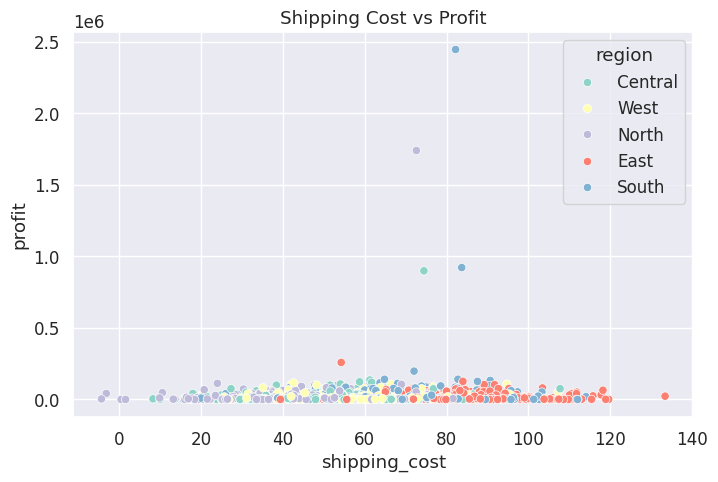

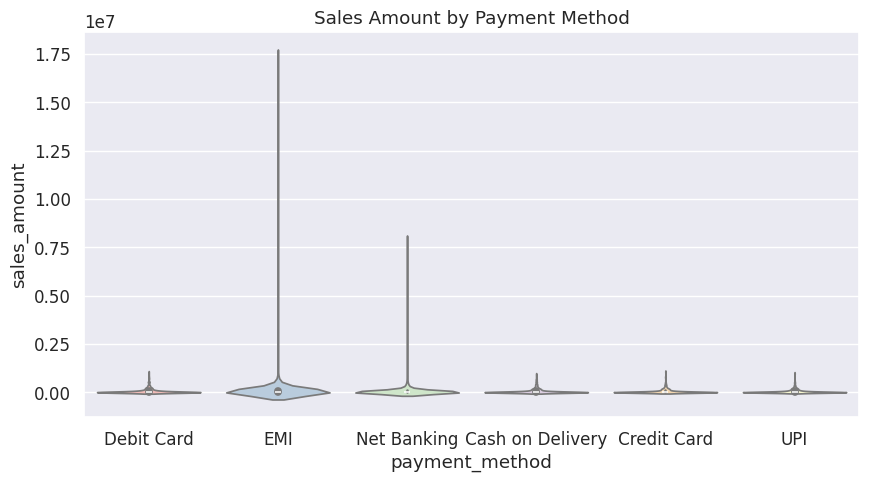

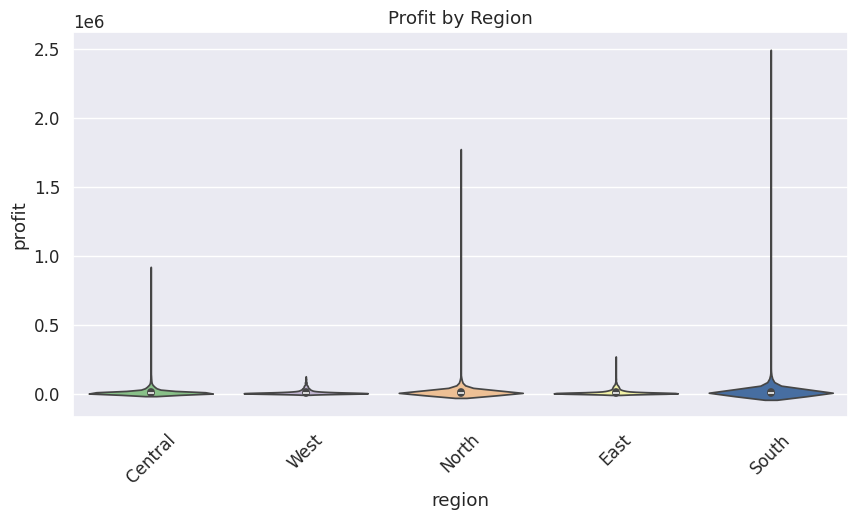

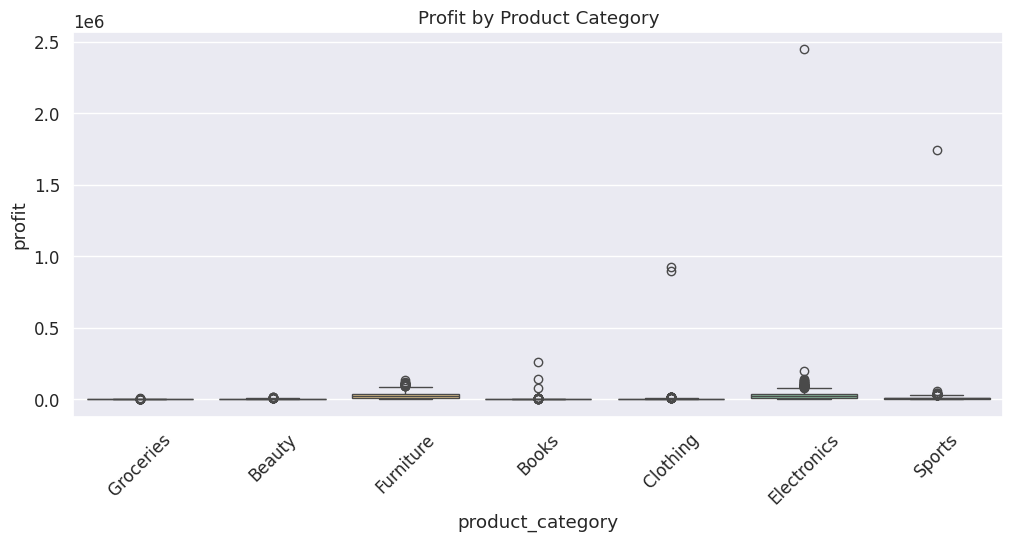

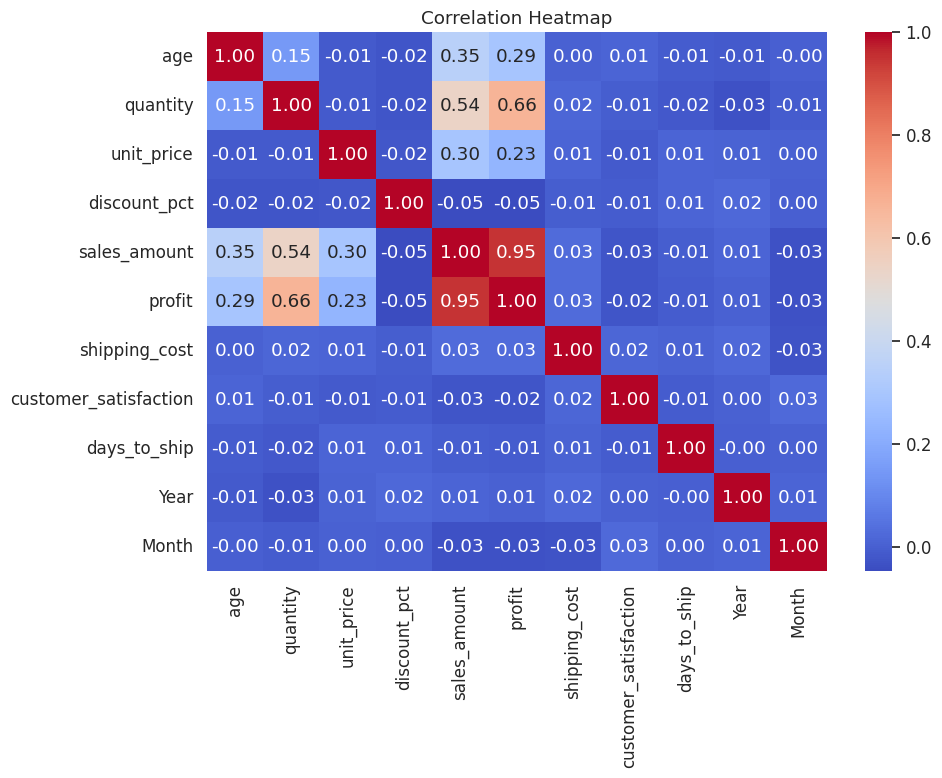

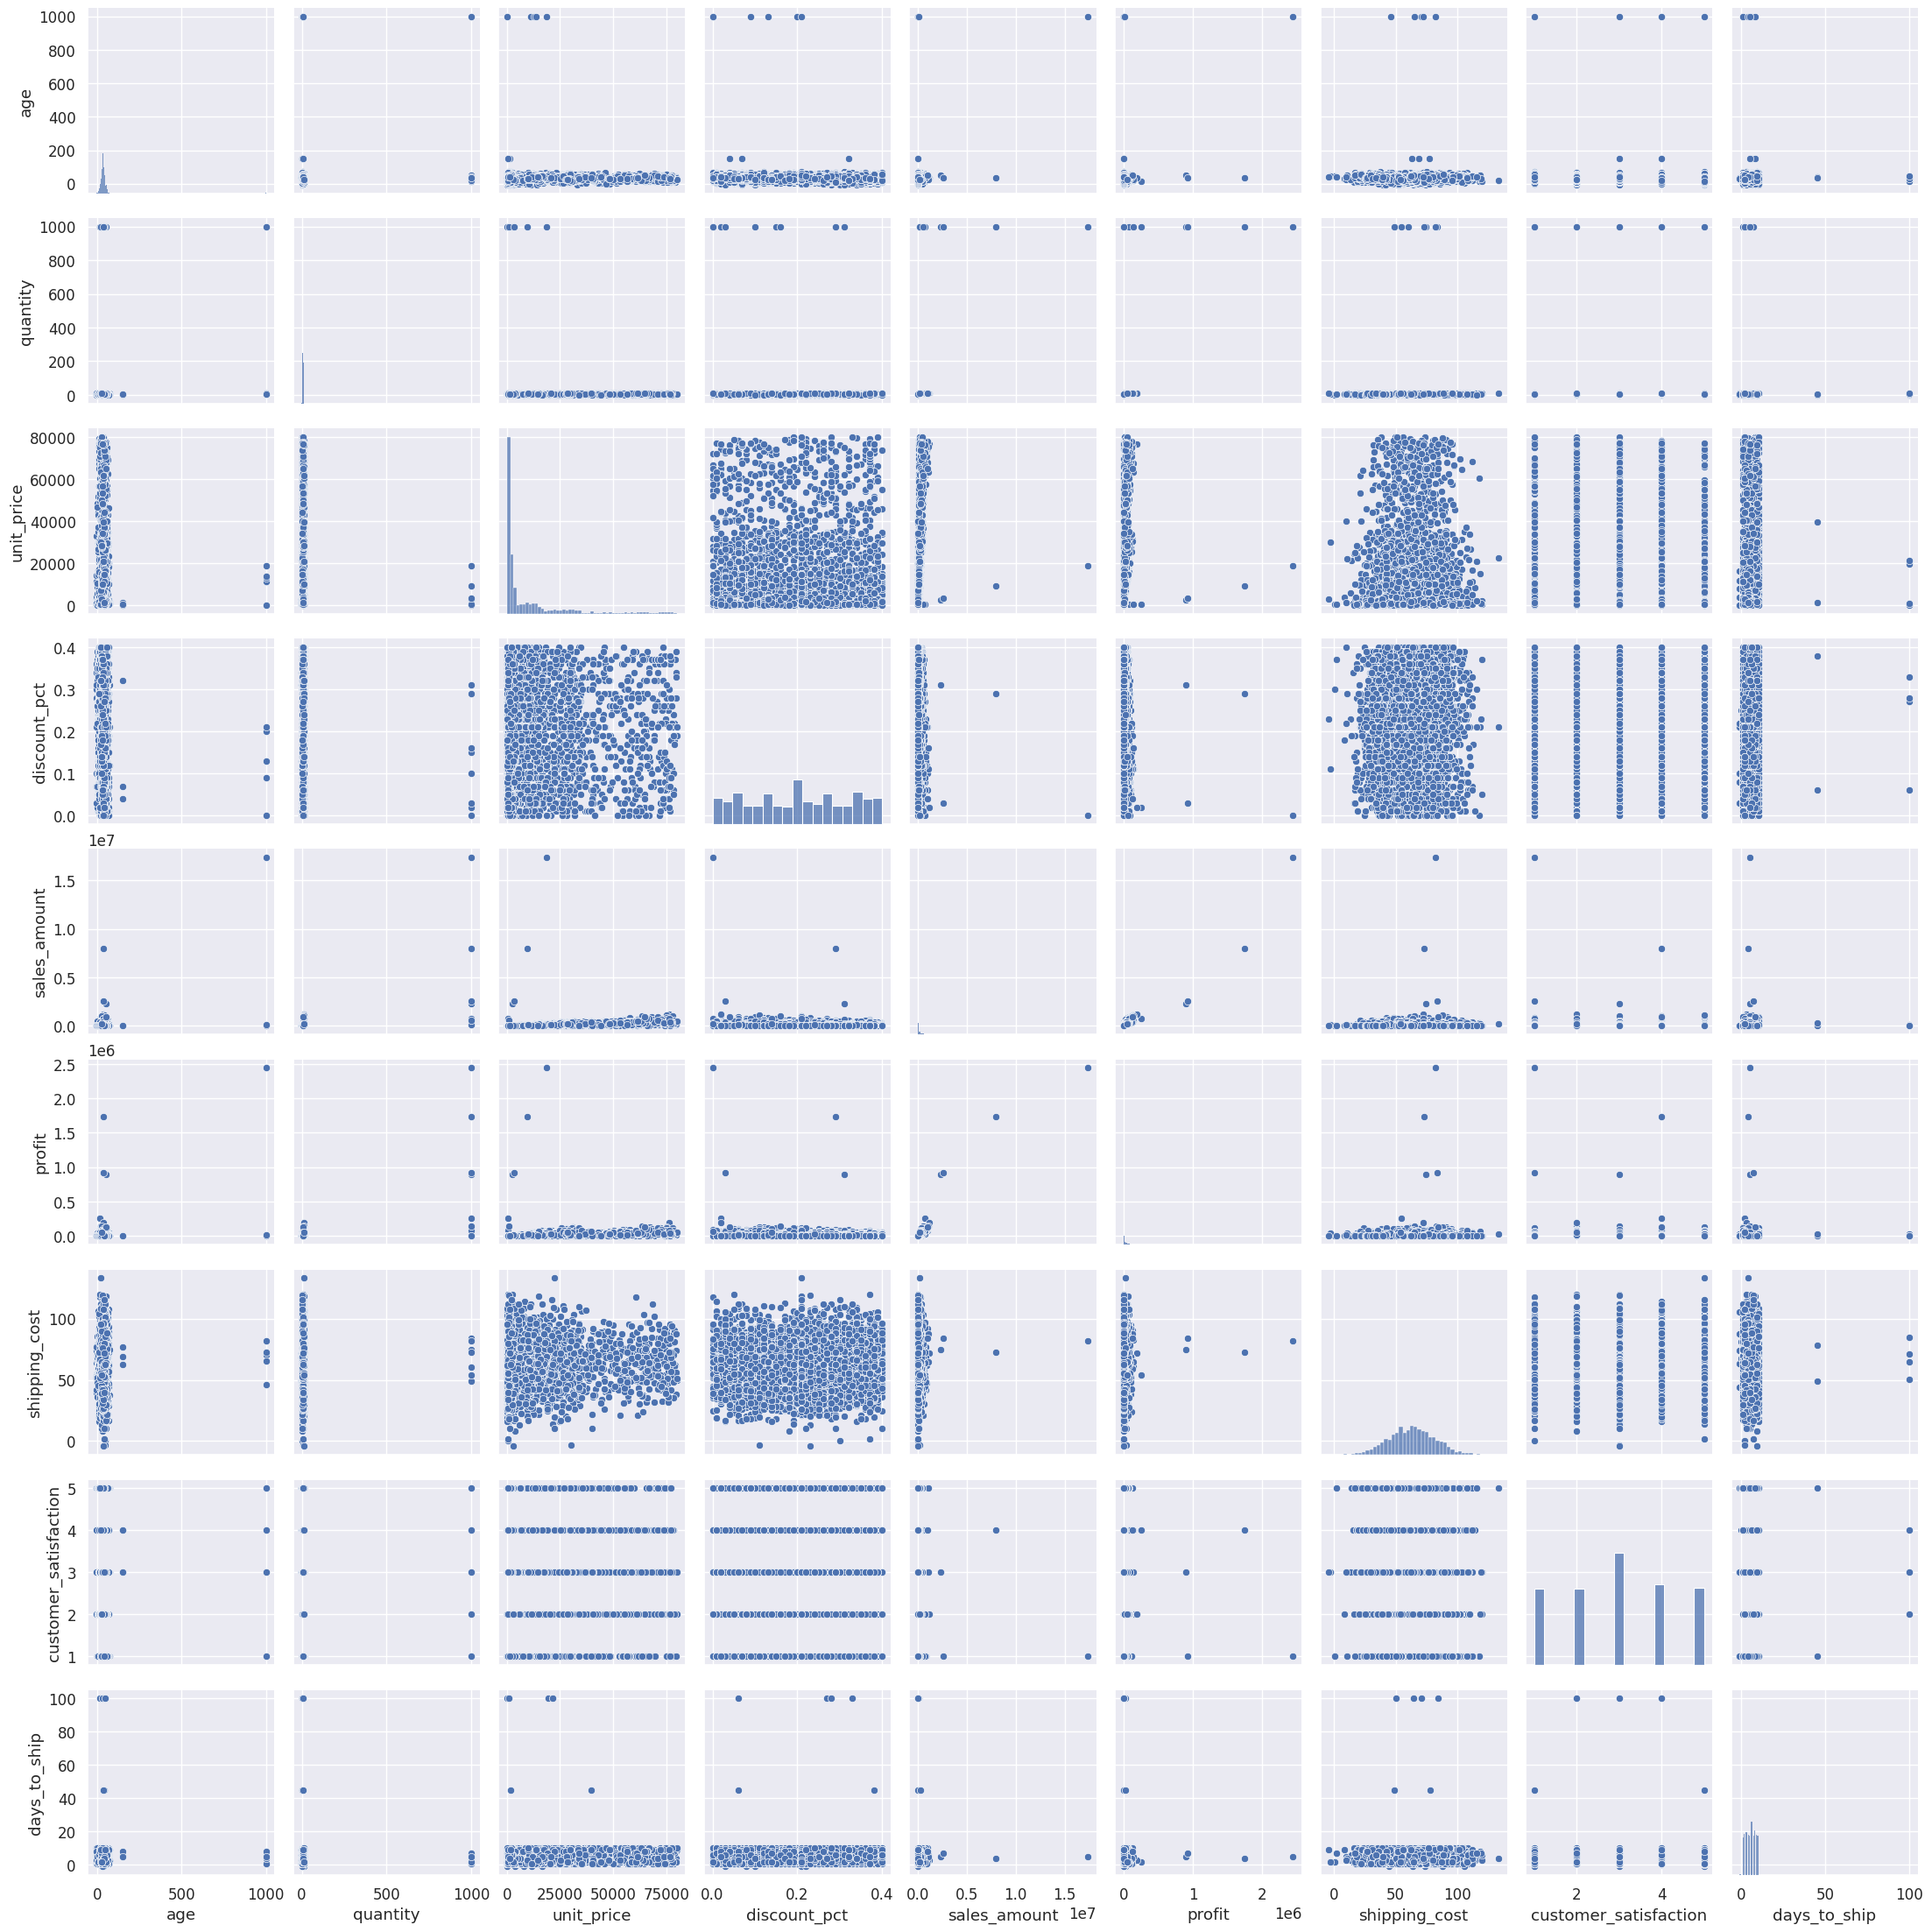

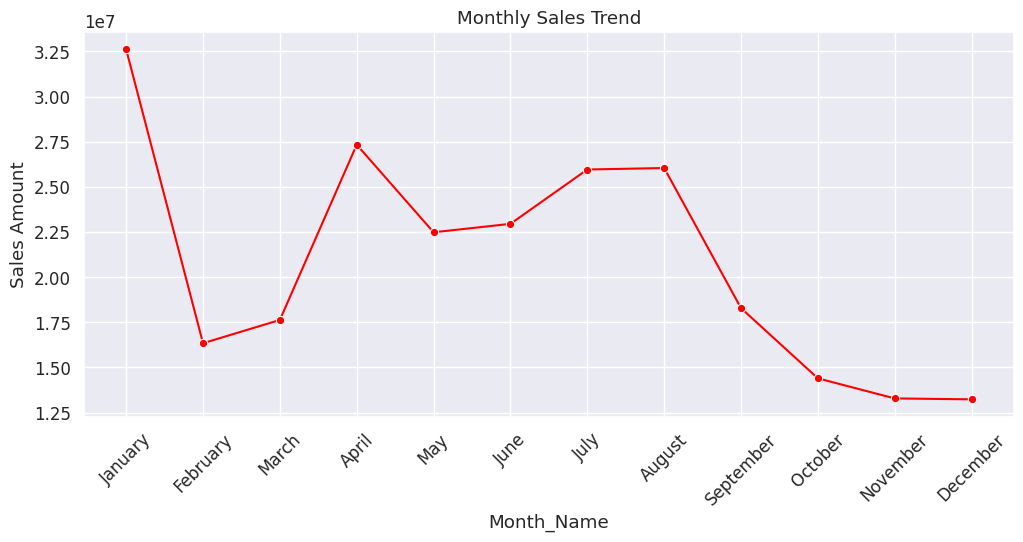

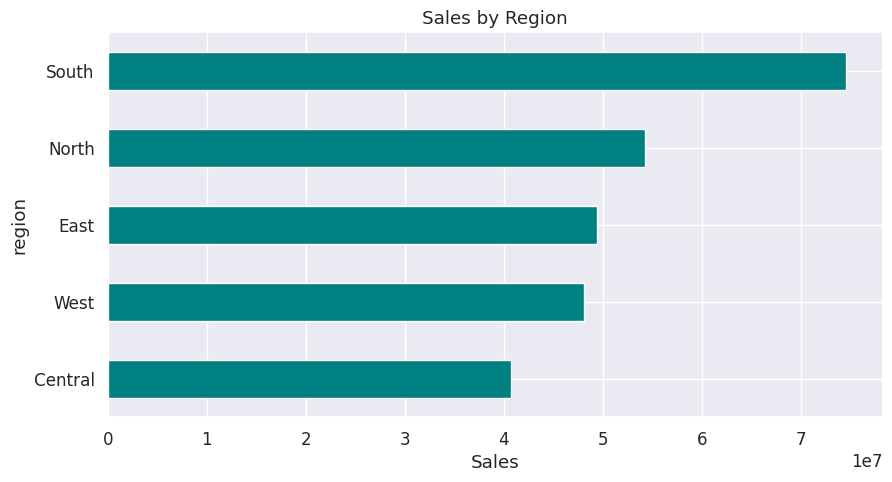

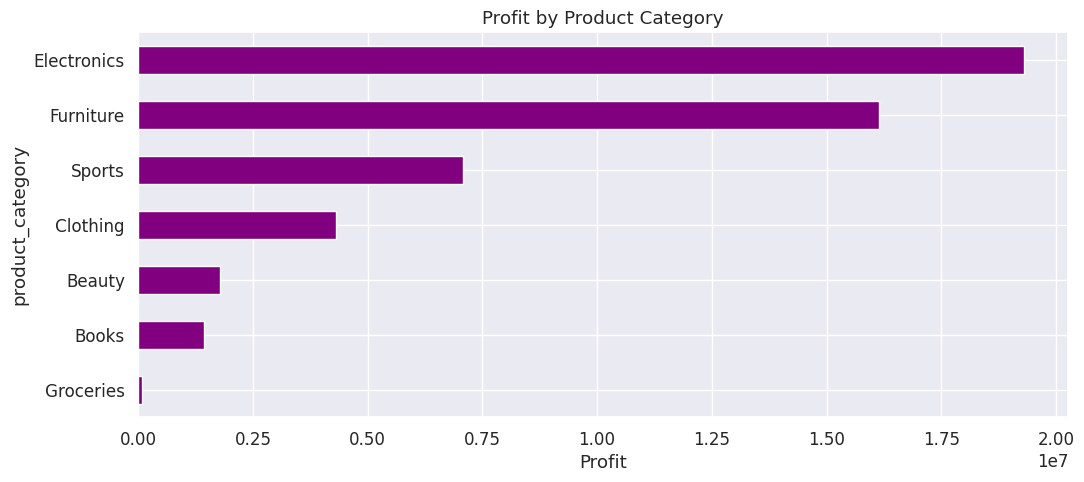

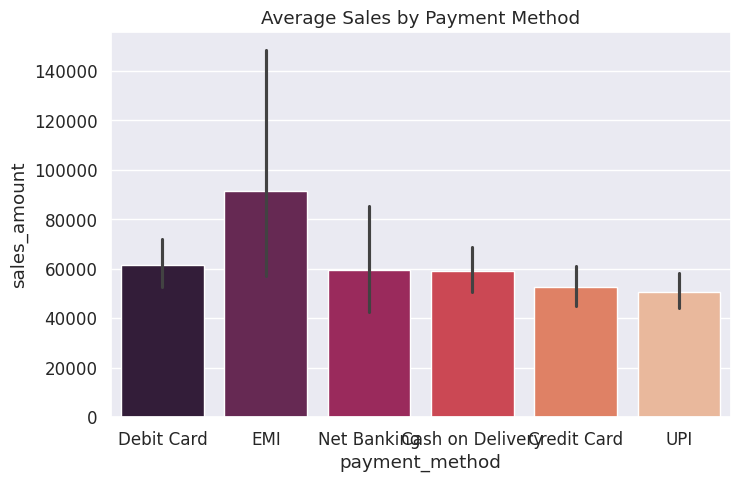

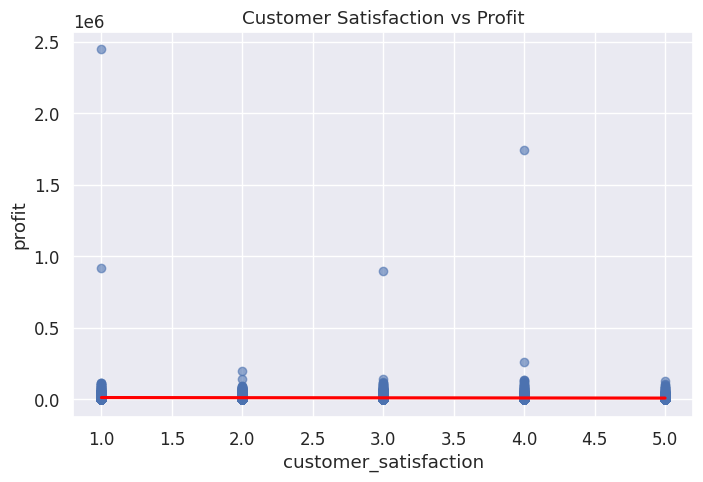

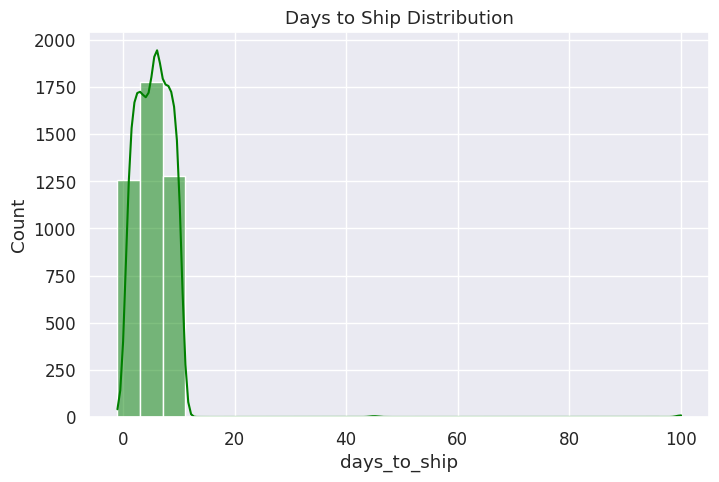

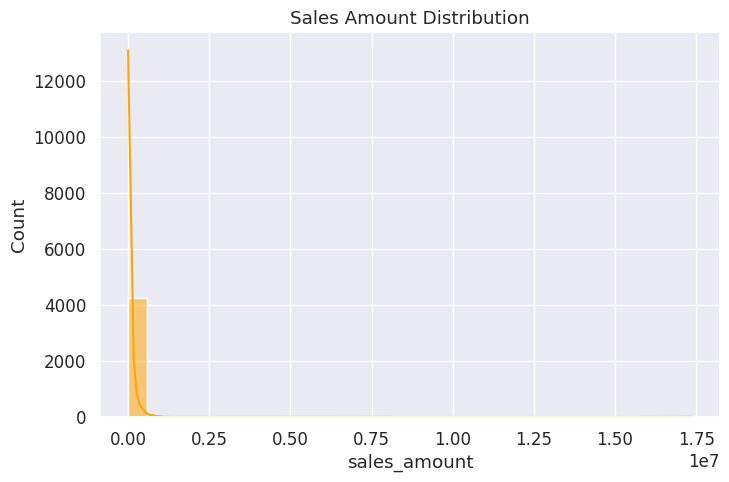

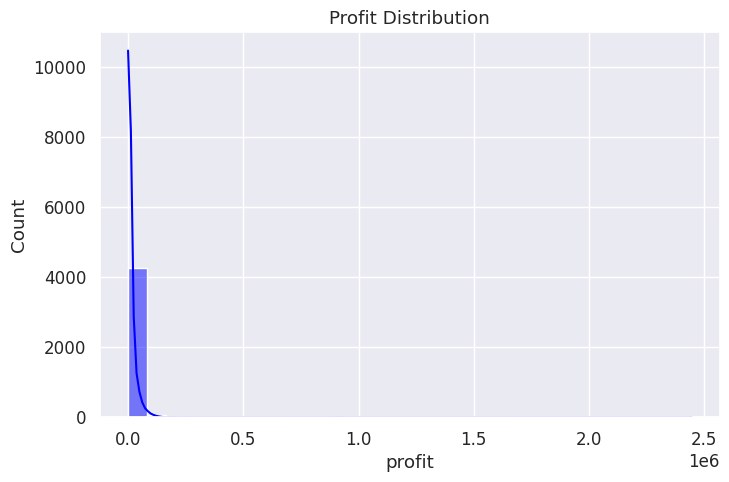

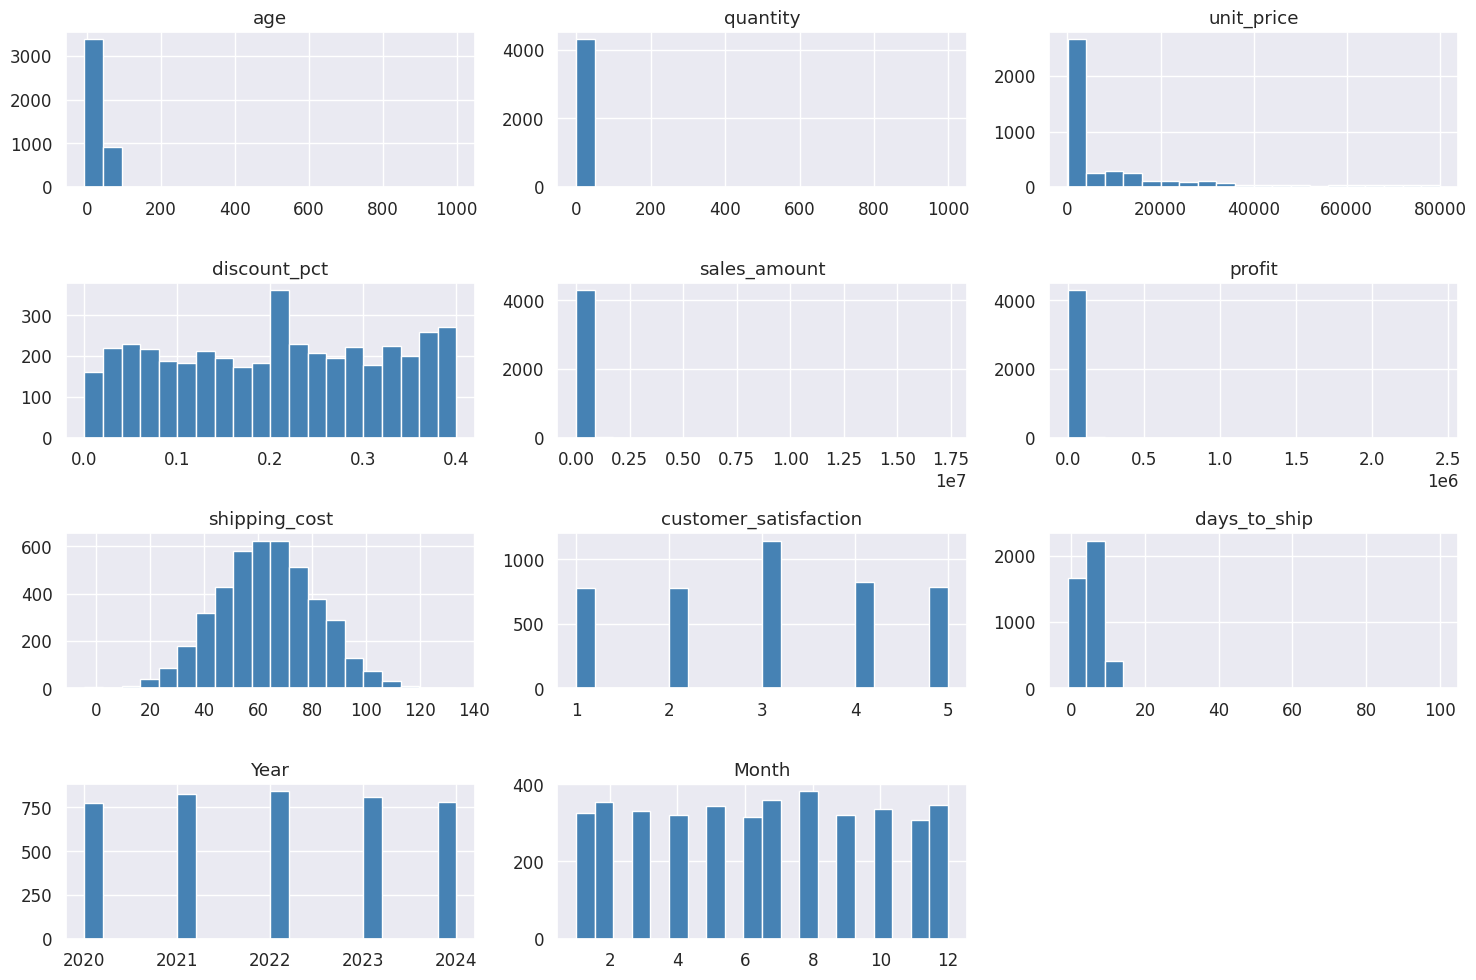

SALES DATASET EDA COMPLETED SUCCESSFULLY


In [14]:
# ==========================================================
# SALES DATASET EDA - PART 3
# ADVANCED VISUALIZATIONS
# ==========================================================

# ==========================
# DATE FEATURES
# ==========================

data["Year"] = data["order_date"].dt.year
data["Month"] = data["order_date"].dt.month
data["Month_Name"] = data["order_date"].dt.month_name()

# ==========================================================
# SCATTER PLOTS
# ==========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="sales_amount",
    y="profit",
    hue="product_category",
    palette="Set2"
)

plt.title("Sales Amount vs Profit")

plt.show()

# ----------------------------------------------------------

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="discount_pct",
    y="sales_amount",
    hue="payment_method",
    palette="tab10"
)

plt.title("Discount vs Sales Amount")

plt.show()

# ----------------------------------------------------------

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="shipping_cost",
    y="profit",
    hue="region",
    palette="Set3"
)

plt.title("Shipping Cost vs Profit")

plt.show()

# ==========================================================
# VIOLIN PLOTS
# ==========================================================

plt.figure(figsize=(10,5))

sns.violinplot(
    data=data,
    x="payment_method",
    y="sales_amount",
    hue="payment_method",
    palette="Pastel1",
    legend=False
)

plt.title("Sales Amount by Payment Method")

plt.show()

# ----------------------------------------------------------

plt.figure(figsize=(10,5))

sns.violinplot(
    data=data,
    x="region",
    y="profit",
    hue="region",
    palette="Accent",
    legend=False
)

plt.xticks(rotation=45)

plt.title("Profit by Region")

plt.show()

# ==========================================================
# BOXPLOT
# ==========================================================

plt.figure(figsize=(12,5))

sns.boxplot(
    data=data,
    x="product_category",
    y="profit",
    hue="product_category",
    palette="Spectral",
    legend=False
)

plt.xticks(rotation=45)

plt.title("Profit by Product Category")

plt.show()

# ==========================================================
# CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(10,7))

corr = data.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# ==========================================================
# PAIRPLOT
# ==========================================================

pair_cols = [
    "age",
    "quantity",
    "unit_price",
    "discount_pct",
    "sales_amount",
    "profit",
    "shipping_cost",
    "customer_satisfaction",
    "days_to_ship"
]

sns.pairplot(data[pair_cols])

plt.show()

# ==========================================================
# MONTHLY SALES TREND
# ==========================================================

monthly_sales = (
    data.groupby("Month_Name")["sales_amount"]
    .sum()
)

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = monthly_sales.reindex(
    [m for m in month_order if m in monthly_sales.index]
)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o",
    color="red"
)

plt.title("Monthly Sales Trend")

plt.xticks(rotation=45)

plt.ylabel("Sales Amount")

plt.grid(True)

plt.show()

# ==========================================================
# REGION WISE SALES
# ==========================================================

plt.figure(figsize=(10,5))

region_sales = (
    data.groupby("region")["sales_amount"]
    .sum()
    .sort_values()
)

region_sales.plot(
    kind="barh",
    color="teal"
)

plt.title("Sales by Region")

plt.xlabel("Sales")

plt.show()

# ==========================================================
# PRODUCT CATEGORY WISE PROFIT
# ==========================================================

plt.figure(figsize=(12,5))

category_profit = (
    data.groupby("product_category")["profit"]
    .sum()
    .sort_values()
)

category_profit.plot(
    kind="barh",
    color="purple"
)

plt.title("Profit by Product Category")

plt.xlabel("Profit")

plt.show()

# ==========================================================
# PAYMENT METHOD VS SALES
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=data,
    x="payment_method",
    y="sales_amount",
    hue="payment_method",
    palette="rocket",
    legend=False
)

plt.title("Average Sales by Payment Method")

plt.show()

# ==========================================================
# CUSTOMER SATISFACTION VS PROFIT
# ==========================================================

plt.figure(figsize=(8,5))

sns.regplot(
    data=data,
    x="customer_satisfaction",
    y="profit",
    scatter_kws={"alpha":0.6},
    line_kws={"color":"red"}
)

plt.title("Customer Satisfaction vs Profit")

plt.show()

# ==========================================================
# SHIPPING DAYS DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["days_to_ship"],
    bins=25,
    kde=True,
    color="green"
)

plt.title("Days to Ship Distribution")

plt.show()

# ==========================================================
# SALES DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["sales_amount"],
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Sales Amount Distribution")

plt.show()

# ==========================================================
# PROFIT DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["profit"],
    bins=30,
    kde=True,
    color="blue"
)

plt.title("Profit Distribution")

plt.show()

# ==========================================================
# NUMERICAL HISTOGRAM GRID
# ==========================================================

data.select_dtypes(include=np.number).hist(
    figsize=(15,10),
    bins=20,
    color="steelblue"
)

plt.tight_layout()

plt.show()

print("="*80)
print("SALES DATASET EDA COMPLETED SUCCESSFULLY")
print("="*80)

## Features Engineering

In [15]:
# ==========================================================
# SALES DATASET ML PIPELINE - PART 1
# ==========================================================

# ==========================
# IMPORT LIBRARIES
# ==========================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ==========================
# ML ALGORITHMS
# ==========================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# ==========================
# COPY DATASET
# ==========================

data = df.copy()

# ==========================
# DATE FEATURE ENGINEERING
# ==========================

data["order_date"] = pd.to_datetime(
    data["order_date"],
    errors="coerce"
)

data["order_year"] = data["order_date"].dt.year
data["order_month"] = data["order_date"].dt.month
data["order_day"] = data["order_date"].dt.day

data.drop(columns=["order_date"], inplace=True)

# ==========================
# DROP ID COLUMNS
# ==========================

drop_cols = [
    "order_id",
    "customer_id",
    "customer_name"
]

for col in drop_cols:
    if col in data.columns:
        data.drop(columns=col, inplace=True)

# ==========================
# HANDLE MISSING VALUES
# ==========================

num_cols = data.select_dtypes(include=np.number).columns
cat_cols = data.select_dtypes(include="object").columns

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

data[num_cols] = num_imputer.fit_transform(data[num_cols])
data[cat_cols] = cat_imputer.fit_transform(data[cat_cols])

# ==========================
# TARGET
# ==========================

target = "order_status"

X = data.drop(columns=[target])
y = data[target]

# ==========================
# TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================
# LABEL ENCODE TARGET
# ==========================

target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

# ==========================
# LABEL ENCODE FEATURES
# ==========================

encoders = {}

cat_features = X_train.select_dtypes(include="object").columns

for col in cat_features:

    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))

    X_test[col] = X_test[col].astype(str)

    known = set(le.classes_)

    X_test[col] = X_test[col].apply(
        lambda x: le.transform([x])[0] if x in known else -1
    )

    encoders[col] = le

# ==========================
# FEATURE SCALING
# ==========================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================
# DEFINE MODELS
# ==========================

models = {

    "Logistic Regression":
    LogisticRegression(max_iter=5000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(random_state=42),

    "Extra Trees":
    ExtraTreesClassifier(
        n_estimators=300,
        random_state=42
    ),

    "AdaBoost":
    AdaBoostClassifier(random_state=42),

    "KNN":
    KNeighborsClassifier(n_neighbors=5),

    "SVM":
    SVC(
        probability=True,
        random_state=42
    ),

    "Naive Bayes":
    GaussianNB()

}

trained_models = {}
results = []

print("="*80)
print("PREPROCESSING COMPLETED SUCCESSFULLY")
print("="*80)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)
print("Target Classes :", target_encoder.classes_)

PREPROCESSING COMPLETED SUCCESSFULLY
Training Shape : (3448, 19)
Testing Shape  : (862, 19)
Target Classes : ['Cancelled' 'Delivered' 'Pending' 'Returned' 'Shipped' 'cancelled'
 'delivered' 'pending' 'shipped']



Logistic Regression
Accuracy  : 0.7680
Precision : 0.5999
Recall    : 0.7680
F1 Score  : 0.6707

Classification Report

              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00        68
   Delivered       0.73      1.00      0.84       539
     Pending       0.00      0.00      0.00        36
    Returned       1.00      0.99      1.00       124
     Shipped       0.00      0.00      0.00        64
   cancelled       0.00      0.00      0.00         3
   delivered       0.00      0.00      0.00        24
     pending       0.00      0.00      0.00         1
     shipped       0.00      0.00      0.00         3

    accuracy                           0.77       862
   macro avg       0.19      0.22      0.20       862
weighted avg       0.60      0.77      0.67       862



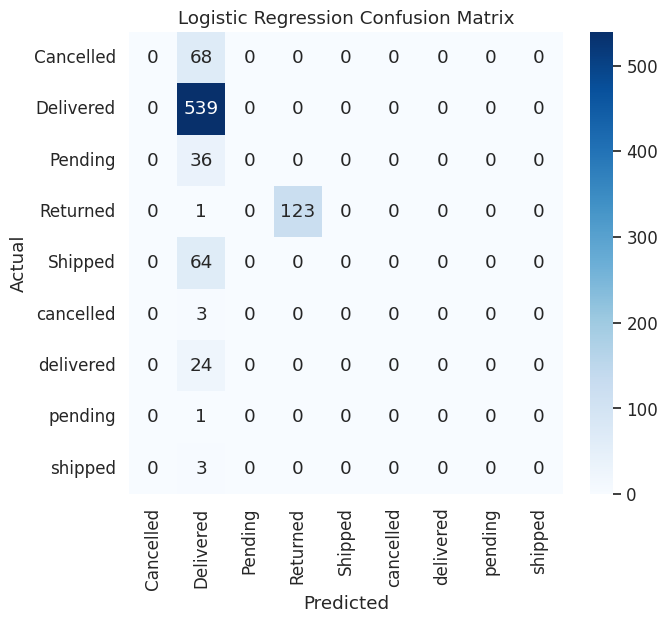

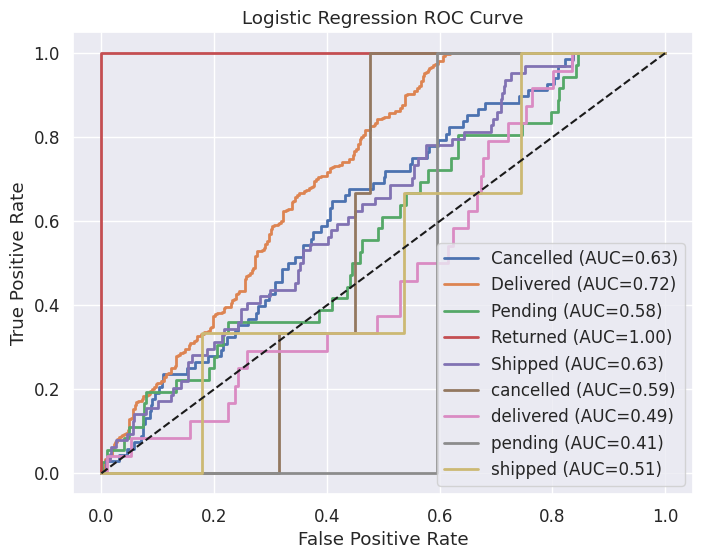


Decision Tree
Accuracy  : 0.6148
Precision : 0.6341
Recall    : 0.6148
F1 Score  : 0.6241

Classification Report

              precision    recall  f1-score   support

   Cancelled       0.15      0.16      0.16        68
   Delivered       0.74      0.71      0.72       539
     Pending       0.02      0.03      0.02        36
    Returned       1.00      1.00      1.00       124
     Shipped       0.16      0.17      0.17        64
   cancelled       0.00      0.00      0.00         3
   delivered       0.07      0.08      0.08        24
     pending       0.00      0.00      0.00         1
     shipped       0.00      0.00      0.00         3

    accuracy                           0.61       862
   macro avg       0.24      0.24      0.24       862
weighted avg       0.63      0.61      0.62       862



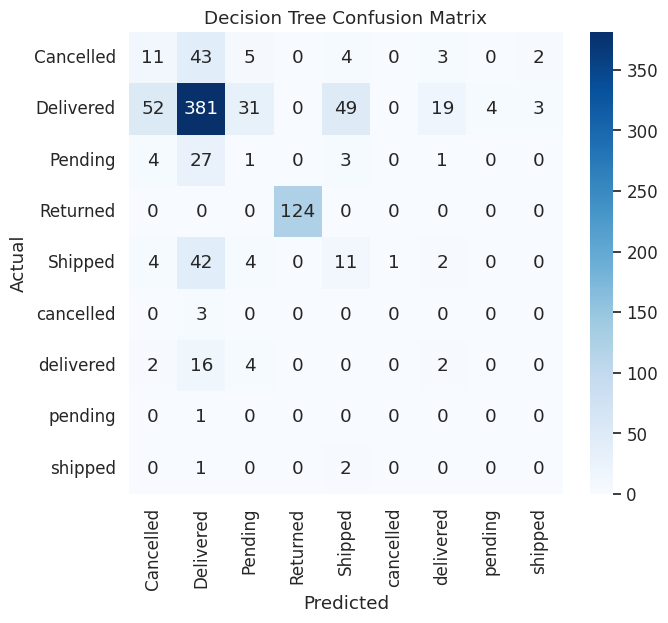

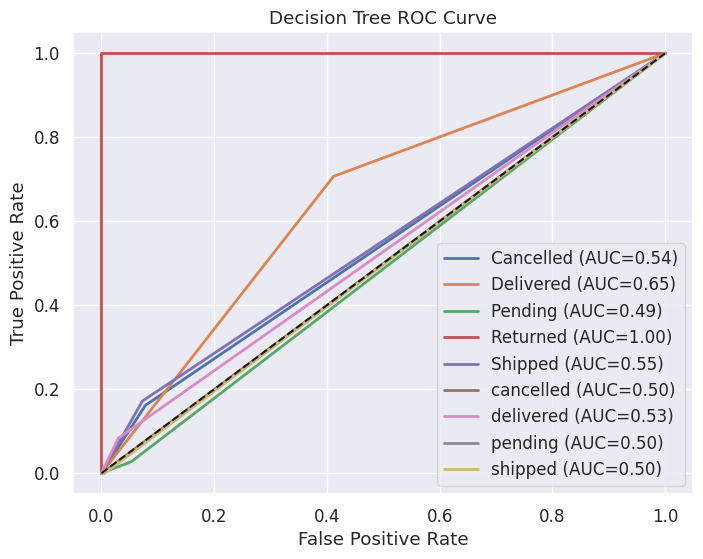


Random Forest
Accuracy  : 0.7761
Precision : 0.7574
Recall    : 0.7761
F1 Score  : 0.6874

Classification Report

              precision    recall  f1-score   support

   Cancelled       1.00      0.03      0.06        68
   Delivered       0.74      1.00      0.85       539
     Pending       0.00      0.00      0.00        36
    Returned       1.00      1.00      1.00       124
     Shipped       1.00      0.06      0.12        64
   cancelled       0.00      0.00      0.00         3
   delivered       0.00      0.00      0.00        24
     pending       0.00      0.00      0.00         1
     shipped       0.00      0.00      0.00         3

    accuracy                           0.78       862
   macro avg       0.42      0.23      0.22       862
weighted avg       0.76      0.78      0.69       862



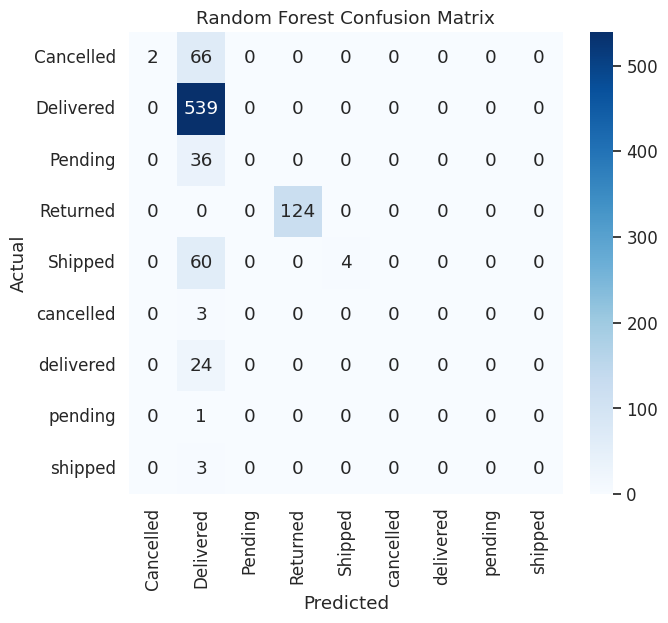

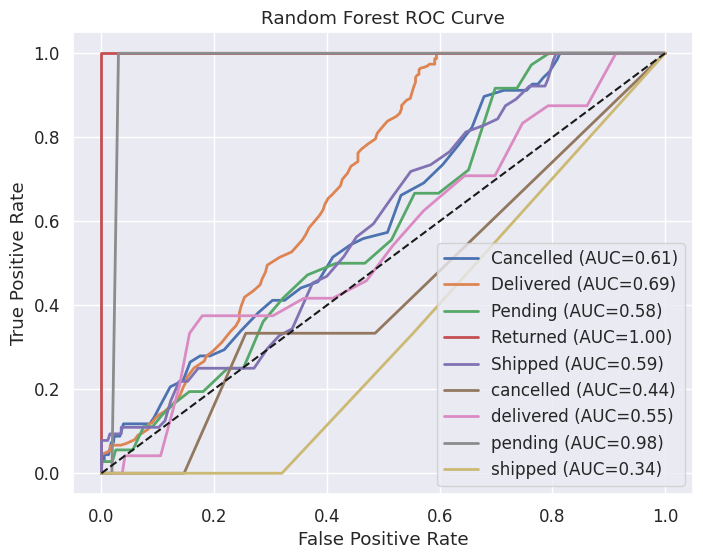


Gradient Boosting
Accuracy  : 0.7622
Precision : 0.6396
Recall    : 0.7622
F1 Score  : 0.6740

Classification Report

              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00        68
   Delivered       0.73      0.99      0.84       539
     Pending       0.00      0.00      0.00        36
    Returned       1.00      1.00      1.00       124
     Shipped       0.50      0.03      0.06        64
   cancelled       0.00      0.00      0.00         3
   delivered       0.00      0.00      0.00        24
     pending       0.00      0.00      0.00         1
     shipped       0.00      0.00      0.00         3

    accuracy                           0.76       862
   macro avg       0.25      0.22      0.21       862
weighted avg       0.64      0.76      0.67       862



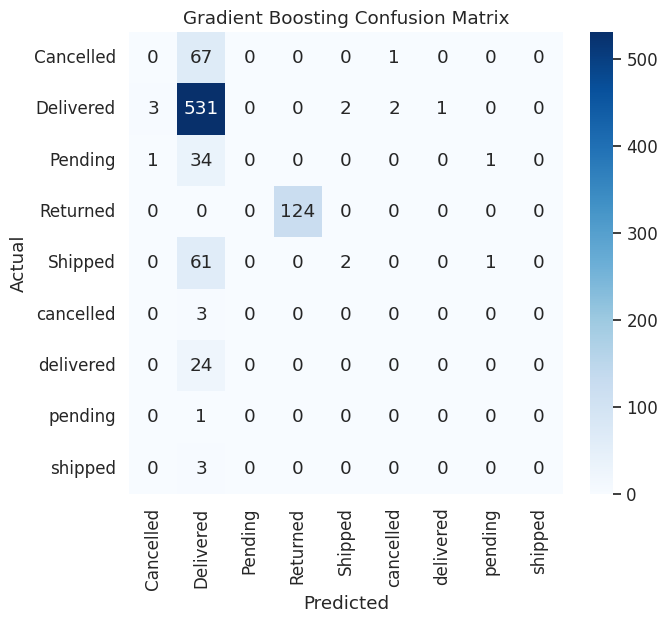

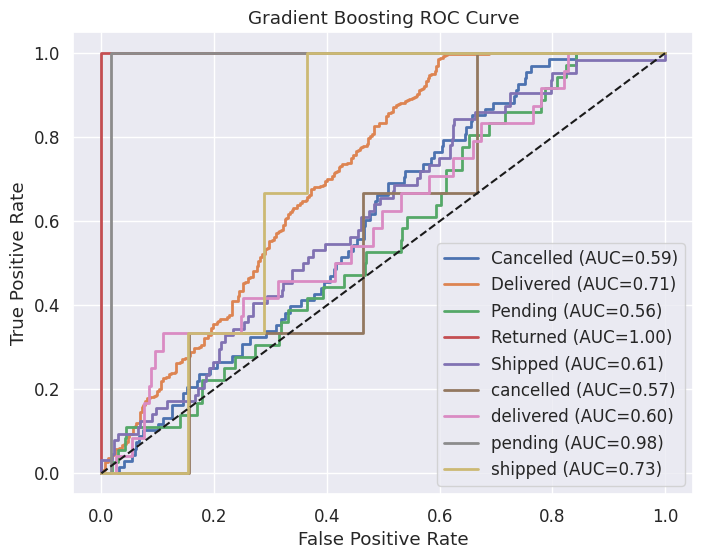


Extra Trees
Accuracy  : 0.7761
Precision : 0.7574
Recall    : 0.7761
F1 Score  : 0.6874

Classification Report

              precision    recall  f1-score   support

   Cancelled       1.00      0.03      0.06        68
   Delivered       0.74      1.00      0.85       539
     Pending       0.00      0.00      0.00        36
    Returned       1.00      1.00      1.00       124
     Shipped       1.00      0.06      0.12        64
   cancelled       0.00      0.00      0.00         3
   delivered       0.00      0.00      0.00        24
     pending       0.00      0.00      0.00         1
     shipped       0.00      0.00      0.00         3

    accuracy                           0.78       862
   macro avg       0.42      0.23      0.22       862
weighted avg       0.76      0.78      0.69       862



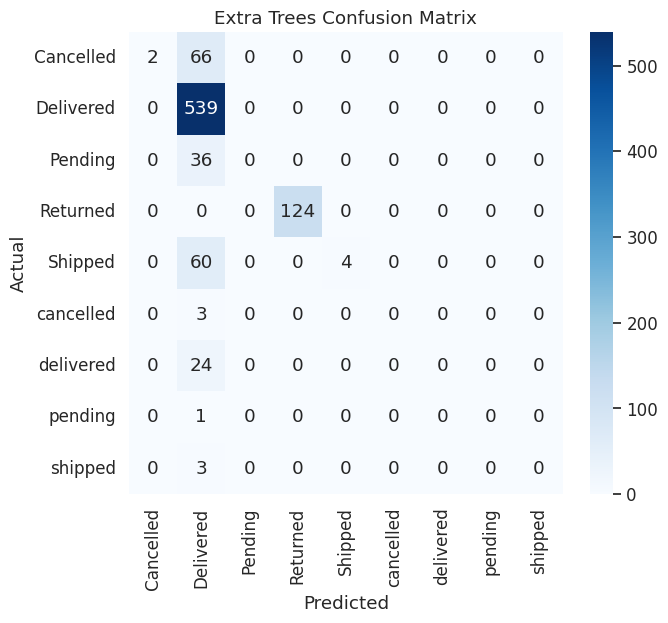

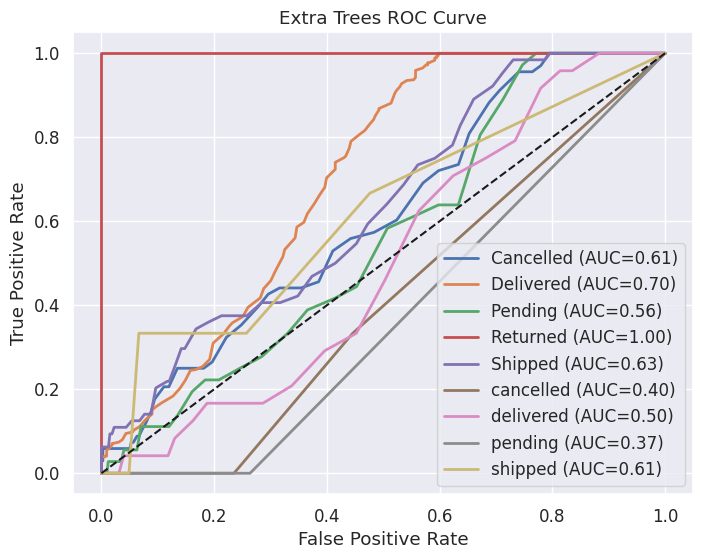


AdaBoost
Accuracy  : 0.7599
Precision : 0.5993
Recall    : 0.7599
F1 Score  : 0.6676

Classification Report

              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00        68
   Delivered       0.73      0.99      0.84       539
     Pending       0.00      0.00      0.00        36
    Returned       1.00      1.00      1.00       124
     Shipped       0.00      0.00      0.00        64
   cancelled       0.00      0.00      0.00         3
   delivered       0.00      0.00      0.00        24
     pending       0.00      0.00      0.00         1
     shipped       0.00      0.00      0.00         3

    accuracy                           0.76       862
   macro avg       0.19      0.22      0.20       862
weighted avg       0.60      0.76      0.67       862



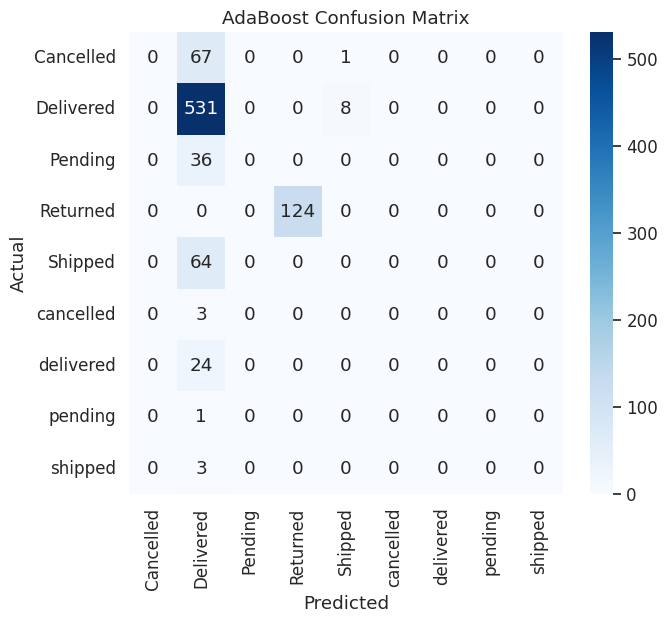

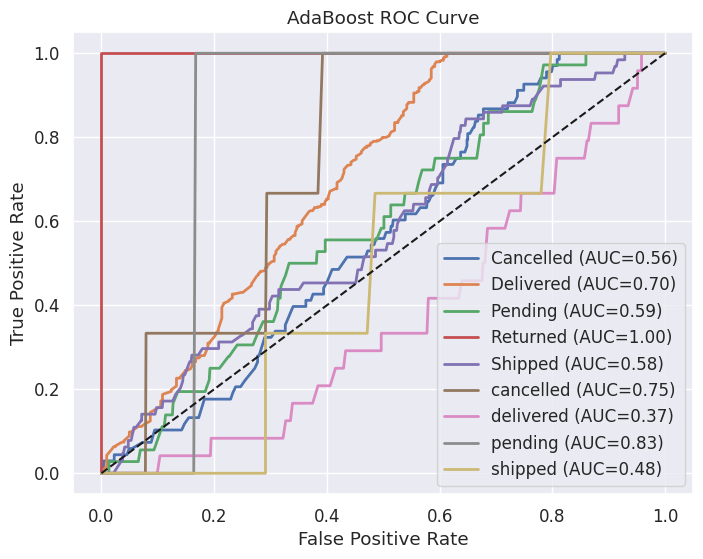


KNN
Accuracy  : 0.7436
Precision : 0.6230
Recall    : 0.7436
F1 Score  : 0.6676

Classification Report

              precision    recall  f1-score   support

   Cancelled       0.17      0.06      0.09        68
   Delivered       0.73      0.96      0.83       539
     Pending       0.00      0.00      0.00        36
    Returned       1.00      0.98      0.99       124
     Shipped       0.14      0.02      0.03        64
   cancelled       0.00      0.00      0.00         3
   delivered       0.00      0.00      0.00        24
     pending       0.00      0.00      0.00         1
     shipped       0.00      0.00      0.00         3

    accuracy                           0.74       862
   macro avg       0.23      0.22      0.21       862
weighted avg       0.62      0.74      0.67       862



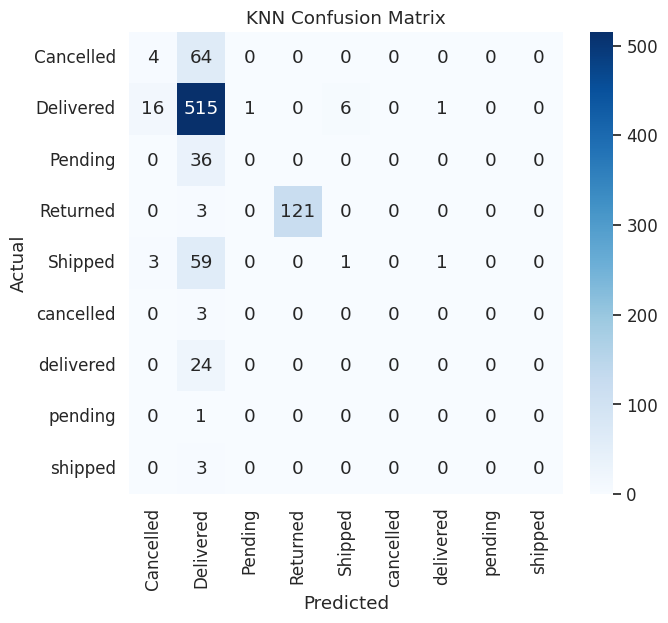

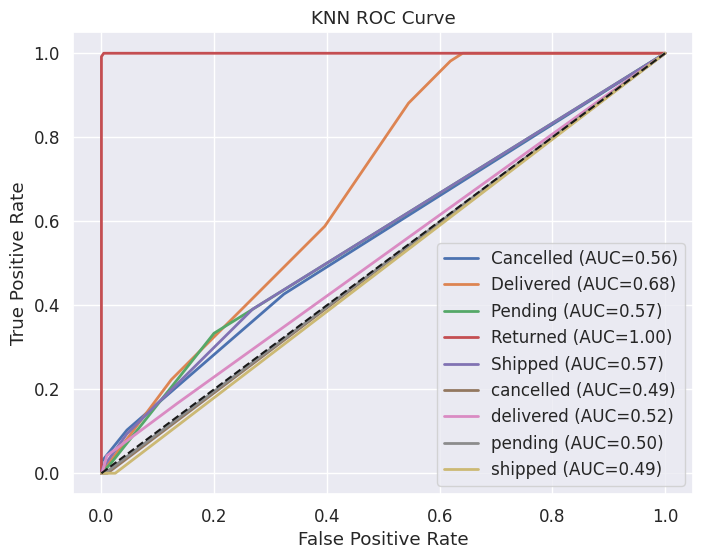


SVM
Accuracy  : 0.7680
Precision : 0.5999
Recall    : 0.7680
F1 Score  : 0.6707

Classification Report

              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00        68
   Delivered       0.73      1.00      0.84       539
     Pending       0.00      0.00      0.00        36
    Returned       1.00      0.99      1.00       124
     Shipped       0.00      0.00      0.00        64
   cancelled       0.00      0.00      0.00         3
   delivered       0.00      0.00      0.00        24
     pending       0.00      0.00      0.00         1
     shipped       0.00      0.00      0.00         3

    accuracy                           0.77       862
   macro avg       0.19      0.22      0.20       862
weighted avg       0.60      0.77      0.67       862



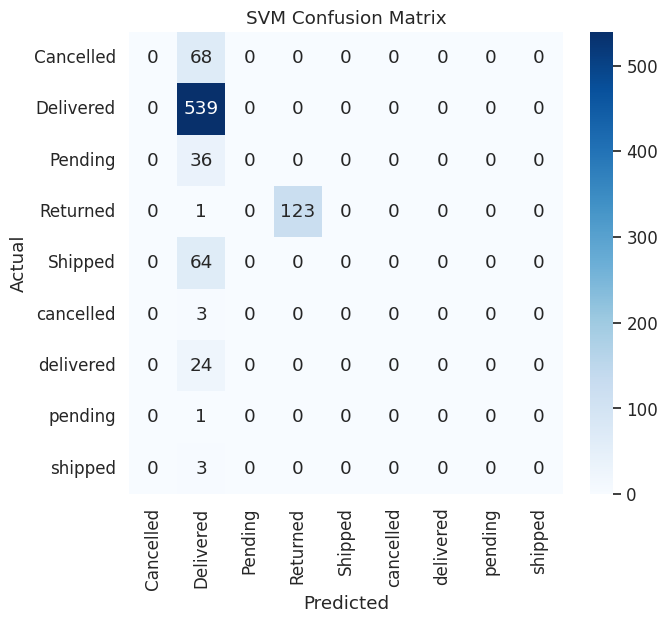

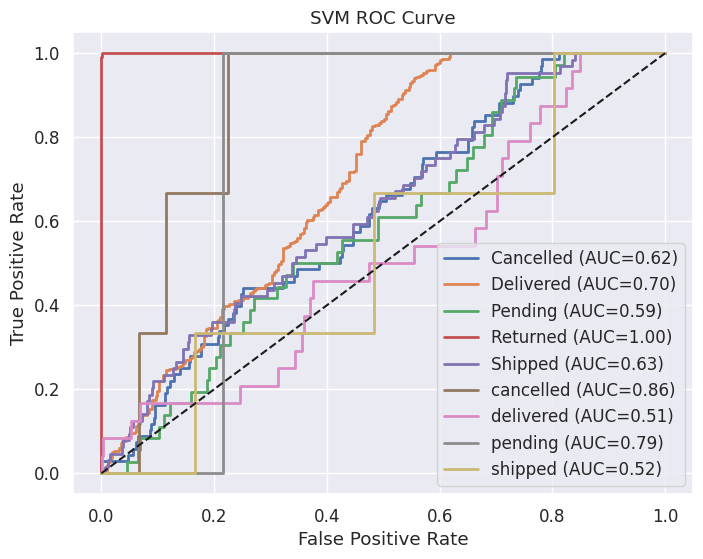


Naive Bayes
Accuracy  : 0.2378
Precision : 0.6639
Recall    : 0.2378
F1 Score  : 0.2426

Classification Report

              precision    recall  f1-score   support

   Cancelled       0.10      0.57      0.18        68
   Delivered       0.79      0.06      0.11       539
     Pending       0.22      0.11      0.15        36
    Returned       1.00      1.00      1.00       124
     Shipped       0.15      0.08      0.10        64
   cancelled       0.00      0.00      0.00         3
   delivered       0.00      0.00      0.00        24
     pending       0.00      0.00      0.00         1
     shipped       0.00      0.00      0.00         3

    accuracy                           0.24       862
   macro avg       0.25      0.20      0.17       862
weighted avg       0.66      0.24      0.24       862



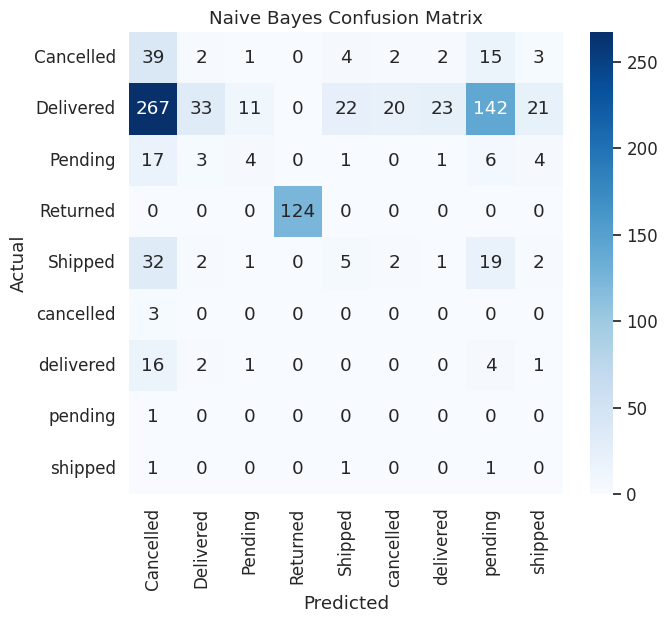

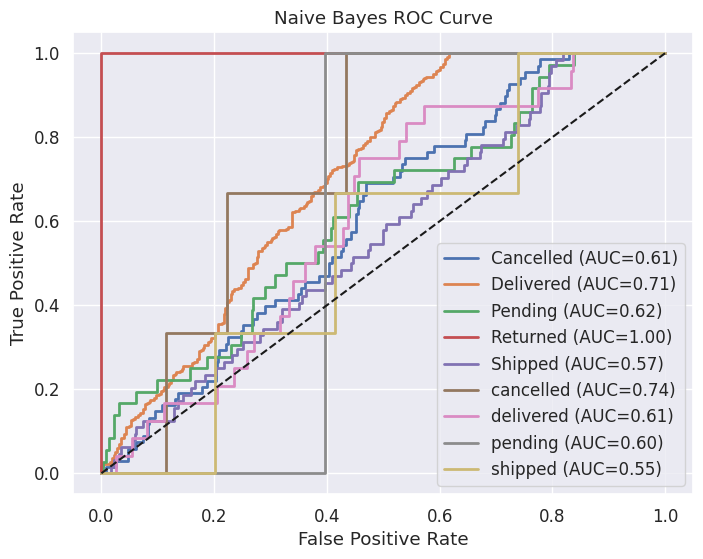



MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score
2        Random Forest  0.776102   0.757409  0.776102  0.687435
4          Extra Trees  0.776102   0.757409  0.776102  0.687435
0  Logistic Regression  0.767981   0.599916  0.767981  0.670705
7                  SVM  0.767981   0.599916  0.767981  0.670705
3    Gradient Boosting  0.762181   0.639578  0.762181  0.673997
5             AdaBoost  0.759861   0.599310  0.759861  0.667557
6                  KNN  0.743619   0.623014  0.743619  0.667595
1        Decision Tree  0.614849   0.634058  0.614849  0.624145
8          Naive Bayes  0.237819   0.663863  0.237819  0.242583


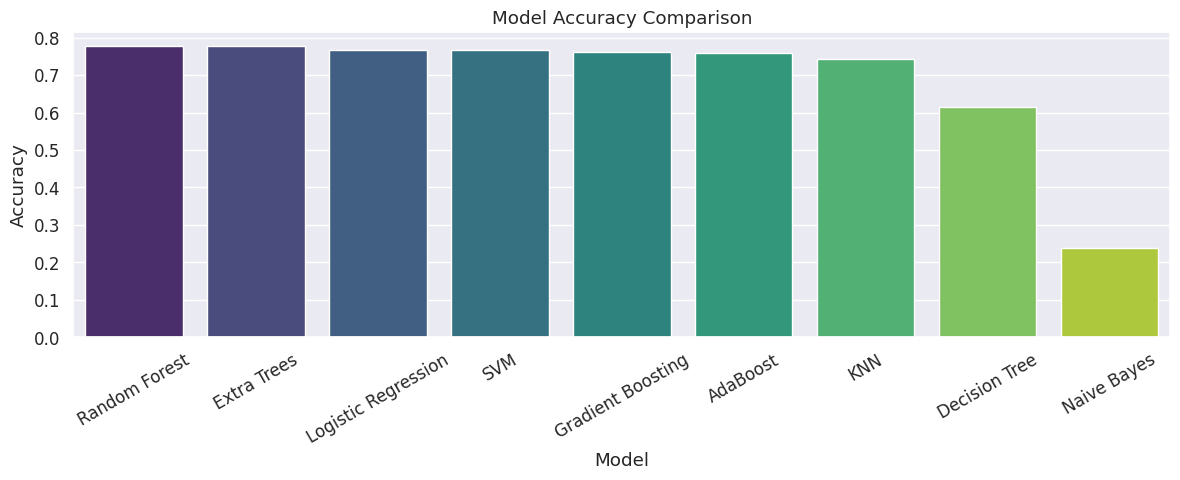

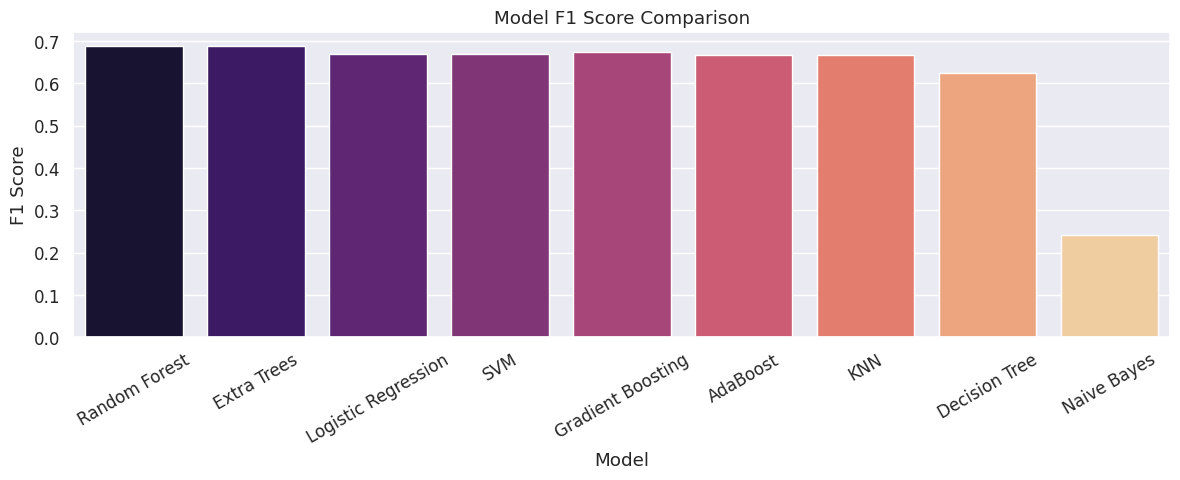

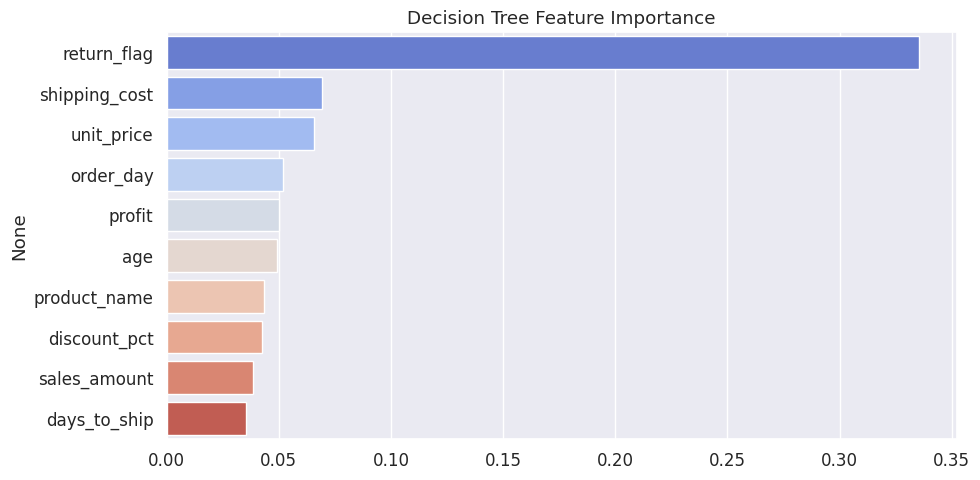

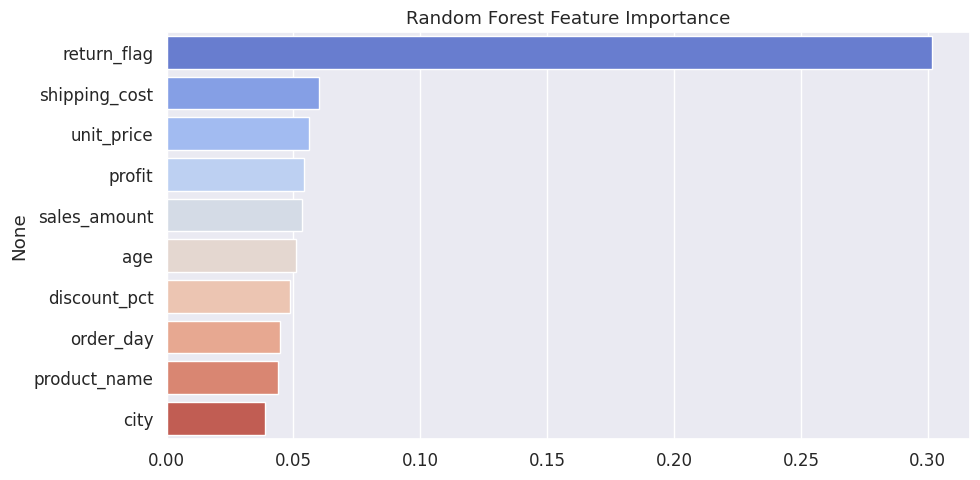

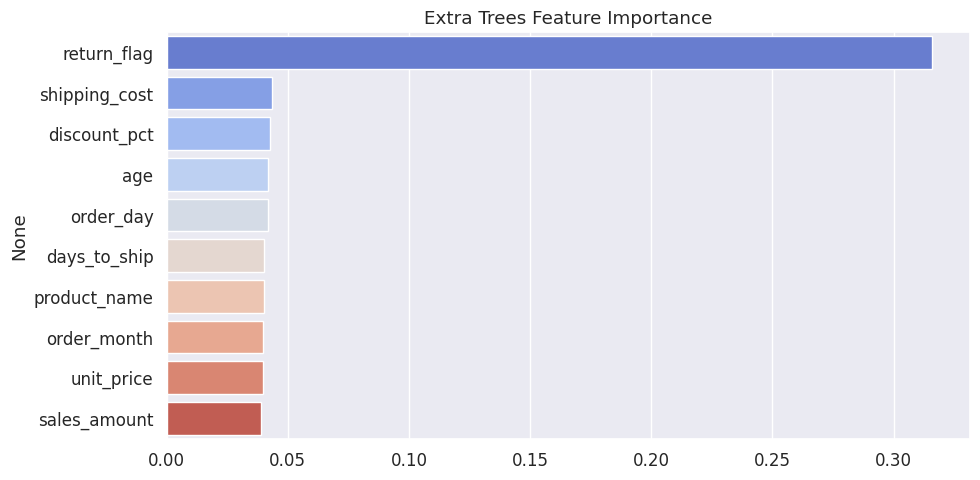


BEST MODEL
Model        Random Forest
Accuracy          0.776102
Precision         0.757409
Recall            0.776102
F1 Score          0.687435
Name: 2, dtype: object

Best Model : Random Forest
Accuracy   : 0.7761
Precision  : 0.7574
Recall     : 0.7761
F1 Score   : 0.6874

Results saved as Sales_ML_Model_Comparison.csv

MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY


In [16]:
# ==========================================================
# SALES DATASET ML PIPELINE - PART 2
# TRAINING + EVALUATION + ROC CURVE
# ==========================================================

results = []

n_classes = len(target_encoder.classes_)

for name, model in models.items():

    print("\n" + "="*80)
    print(name)
    print("="*80)

    # ==========================
    # TRAIN MODEL
    # ==========================

    model.fit(X_train, y_train)

    trained_models[name] = model

    # ==========================
    # PREDICTIONS
    # ==========================

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    # ==========================
    # CLASSIFICATION REPORT
    # ==========================

    labels = np.unique(np.concatenate((y_test, y_pred)))

    print("\nClassification Report\n")

    print(
        classification_report(
            y_test,
            y_pred,
            labels=labels,
            target_names=target_encoder.inverse_transform(labels),
            zero_division=0
        )
    )

    # ==========================
    # CONFUSION MATRIX
    # ==========================

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=labels
    )

    plt.figure(figsize=(7,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_encoder.inverse_transform(labels),
        yticklabels=target_encoder.inverse_transform(labels)
    )

    plt.title(name + " Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # ==========================
    # ROC CURVE
    # ==========================

    if hasattr(model, "predict_proba"):

        y_score = model.predict_proba(X_test)

        y_bin = label_binarize(
            y_test,
            classes=np.arange(n_classes)
        )

        plt.figure(figsize=(8,6))

        if n_classes == 2:

            fpr, tpr, _ = roc_curve(
                y_bin[:,1],
                y_score[:,1]
            )

            roc_auc = auc(fpr, tpr)

            plt.plot(
                fpr,
                tpr,
                label=f"AUC = {roc_auc:.3f}",
                linewidth=2
            )

        else:

            for i in range(n_classes):

                if np.sum(y_bin[:, i]) == 0:
                    continue

                fpr, tpr, _ = roc_curve(
                    y_bin[:, i],
                    y_score[:, i]
                )

                roc_auc = auc(fpr, tpr)

                plt.plot(
                    fpr,
                    tpr,
                    linewidth=2,
                    label=f"{target_encoder.classes_[i]} (AUC={roc_auc:.2f})"
                )

        plt.plot([0,1],[0,1],"k--")

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(name + " ROC Curve")
        plt.legend(loc="lower right")
        plt.grid(True)

        plt.show()

# ==========================================================
# MODEL COMPARISON
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*80)
print("MODEL COMPARISON")
print("="*80)

print(results_df)

# ==========================================================
# ACCURACY BAR CHART
# ==========================================================

plt.figure(figsize=(12,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.xticks(rotation=30)

plt.title("Model Accuracy Comparison")

plt.tight_layout()

plt.show()

# ==========================================================
# F1 SCORE BAR CHART
# ==========================================================

plt.figure(figsize=(12,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score",
    hue="Model",
    palette="magma",
    legend=False
)

plt.xticks(rotation=30)

plt.title("Model F1 Score Comparison")

plt.tight_layout()

plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

feature_names = X.columns

for model_name in ["Decision Tree", "Random Forest", "Extra Trees"]:

    if model_name in trained_models:

        model = trained_models[model_name]

        importance = pd.Series(
            model.feature_importances_,
            index=feature_names
        ).sort_values(ascending=False)

        plt.figure(figsize=(10,5))

        sns.barplot(
            x=importance.head(10).values,
            y=importance.head(10).index,
            hue=importance.head(10).index,
            palette="coolwarm",
            legend=False
        )

        plt.title(model_name + " Feature Importance")

        plt.tight_layout()

        plt.show()

# ==========================================================
# BEST MODEL
# ==========================================================

best_model = results_df.iloc[0]

print("\n" + "="*80)
print("BEST MODEL")
print("="*80)

print(best_model)

print(f"\nBest Model : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Precision  : {best_model['Precision']:.4f}")
print(f"Recall     : {best_model['Recall']:.4f}")
print(f"F1 Score   : {best_model['F1 Score']:.4f}")

# ==========================================================
# SAVE RESULTS
# ==========================================================

results_df.to_csv(
    "Sales_ML_Model_Comparison.csv",
    index=False
)

print("\nResults saved as Sales_ML_Model_Comparison.csv")

print("\n" + "="*80)
print("MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY")
print("="*80)

## Thanks........Please Upvote